# Hero FinCorp Loan Portfolio Analysis
### Objective:
Perform a comprehensive analysis of Hero FinCorp's loan portfolio and customer behavior to understand default risks, branch efficiency, customer insights, and profitability.

## 1. Data Quality and Preparation


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os




In [3]:
# Files to load
files = ['applications.csv', 'branches.csv', 'customers.csv', 'defaults.csv', 'loans.csv', 'transactions.csv']
dfs = {}

for f in files:
    dfs[f.split('.')[0]] = pd.read_csv(f, low_memory=False)
    print(f"Loaded {f} with shape {dfs[f.split('.')[0]].shape}")

# Shortcut variables
apps = dfs['applications']
branches = dfs['branches']
custs = dfs['customers']
defaults = dfs['defaults']
loans = dfs['loans']
trans = dfs['transactions']

Loaded applications.csv with shape (82600, 10)
Loaded branches.csv with shape (50, 9)
Loaded customers.csv with shape (70000, 14)
Loaded defaults.csv with shape (9000, 9)
Loaded loans.csv with shape (90000, 12)
Loaded transactions.csv with shape (495000, 9)


In [4]:
apps.head()

,Application_ID,Loan_ID,Customer_ID,Application_Date,Approval_Date,Loan_Purpose,Source_Channel,Processing_Fee,Approval_Status,Rejection_Reason
0,A000001,L000001,C000001,2022-05-11,2020-10-02,Business,Agent,6427,Approved,NaN
1,A000002,L000002,C000002,2022-03-18,2022-11-29,Education,Online,8605,Approved,NaN
2,A000003,L000003,C000003,2022-01-17,2023-07-01,Business,Online,1450,Approved,NaN
3,A000004,L000004,C000004,2019-03-09,2024-08-30,Home Renovation,Agent,8171,Approved,NaN
4,A000005,L000005,C000005,2024-07-18,2020-03-18,Education,Branch,4931,Approved,NaN


In [5]:
branches.head()

,Branch_ID,Branch_Name,Region,Total_Customers,Total_Active_Loans,Delinquent_Loans,Loan_Disbursement_Amount,Avg_Processing_Time,Relationship_Manager_Count
0,B001,"Dhar, Kant and Madan",West,2891,279,21,341680882,6,29
1,B002,Shan Group,East,4459,1201,149,96549019,8,35
2,B003,Sachdev-Banerjee,Central,2504,122,168,445787808,12,48
3,B004,Kapadia-Brar,East,1542,1422,96,353934299,9,50
4,B005,"Mangal, Kaur and Borde",South,945,1613,87,311637902,11,10


### Data Cleaning
- Handling missing values
- Standardizing dates
- Converting categorical and string data to numeric where necessary

In [6]:
# Handle missing values in applications
print("\nMissing values in applications:", apps.isnull().sum().sum())


# Handle missing values in branches
print("\nMissing values in branches:", branches.isnull().sum().sum())

# Handle missing values in customers
print("\nMissing values in customers:", custs.isnull().sum().sum())
# Handle missing values in defaults
print("\nMissing values in defaults:", defaults.isnull().sum().sum())
# Handle missing values in loans
print("\nMissing values in loans:", loans.isnull().sum().sum())
# Handle missing values in transactions
print("\nMissing values in transactions:", trans.isnull().sum().sum())


Missing values in applications: 95200

Missing values in branches: 0

Missing values in customers: 0

Missing values in defaults: 2985

Missing values in loans: 30194

Missing values in transactions: 0


In [7]:
# fill  Missing values in Applications with median for numeric and mode for categorical

for col in apps.columns:
    if apps[col].dtype in ['float64', 'int64']:
        median_value = apps[col].median()
        apps[col].fillna(median_value, inplace=True)
    else:
        mode_value = apps[col].mode()[0]
        apps[col].fillna(mode_value, inplace=True)


# fill  Missing values in defaults with median for numeric and mode for categorical        
for col in defaults.columns:
    if defaults[col].dtype in ['float64', 'int64']:
        median_value = defaults[col].median()
        defaults[col].fillna(median_value, inplace=True)
    else:
        mode_value = defaults[col].mode()[0]
        defaults[col].fillna(mode_value, inplace=True)

# fill  Missing values in loans with median for numeric and mode for categorical        
for col in loans.columns:
    if loans[col].dtype in ['float64', 'int64']:
        median_value = loans[col].median()
        loans[col].fillna(median_value, inplace=True)
    else:
        mode_value = loans[col].mode()[0]
        loans[col].fillna(mode_value, inplace=True)



C:\Users\DELL\AppData\Local\Temp\ipykernel_16484\512182210.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  apps[col].fillna(mode_value, inplace=True)
C:\Users\DELL\AppData\Local\Temp\ipykernel_16484\512182210.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when

In [8]:
# Handle missing values in applications
print("\nMissing values in applications:", apps.isnull().sum().sum())


# Handle missing values in branches
print("\nMissing values in branches:", branches.isnull().sum().sum())

# Handle missing values in customers
print("\nMissing values in customers:", custs.isnull().sum().sum())
# Handle missing values in defaults
print("\nMissing values in defaults:", defaults.isnull().sum().sum())
# Handle missing values in loans
print("\nMissing values in loans:", loans.isnull().sum().sum())
# Handle missing values in transactions
print("\nMissing values in transactions:", trans.isnull().sum().sum())


Missing values in applications: 0

Missing values in branches: 0

Missing values in customers: 0

Missing values in defaults: 0

Missing values in loans: 0

Missing values in transactions: 0


In [9]:
def clean_data():
    # 1. Applications
    apps['Application_Date'] = pd.to_datetime(apps['Application_Date'], errors='coerce')
    apps['Approval_Date'] = pd.to_datetime(apps['Approval_Date'], errors='coerce')
    apps['Rejection_Reason'] = apps['Rejection_Reason'].fillna('None')
    
    # 2. Customers
    custs['Account_Tenure_Years'] = custs['Account_Tenure'].str.extract('(\\d+)').astype(float)
    
    # 3. Loans
    loans['Disbursal_Date'] = pd.to_datetime(loans['Disbursal_Date'], errors='coerce')
    loans['Repayment_Start_Date'] = pd.to_datetime(loans['Repayment_Start_Date'], errors='coerce')
    loans['Repayment_End_Date'] = pd.to_datetime(loans['Repayment_End_Date'], errors='coerce')
    loans['Collateral_Details'] = loans['Collateral_Details'].fillna('None')
    
    # 4. Defaults
    defaults['Default_Date'] = pd.to_datetime(defaults['Default_Date'], errors='coerce')
    defaults['Recovery_Status'] = defaults['Recovery_Status'].fillna('Unknown')
    
    # 5. Transactions
    trans['Transaction_Date'] = pd.to_datetime(trans['Transaction_Date'], errors='coerce')
    
    # Outlier handling (IQR Method)
    def handle_outliers(df, column):
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df[column] = np.clip(df[column], lower, upper)
        return df

    loans['Loan_Amount'] = handle_outliers(loans, 'Loan_Amount')['Loan_Amount']
    custs['Annual_Income'] = handle_outliers(custs, 'Annual_Income')['Annual_Income']
    
    print("Data cleaning completed.")

clean_data()


Data cleaning completed.


## 2. Descriptive Analysis
### Summarize and visualize key metrics:
 #### Distribution of Loan_Amount, EMI_Amount, and Credit_Score.
 #### Regional trends in loan disbursement and defaults.
 #### Monthly trends in loan approvals and disbursements.


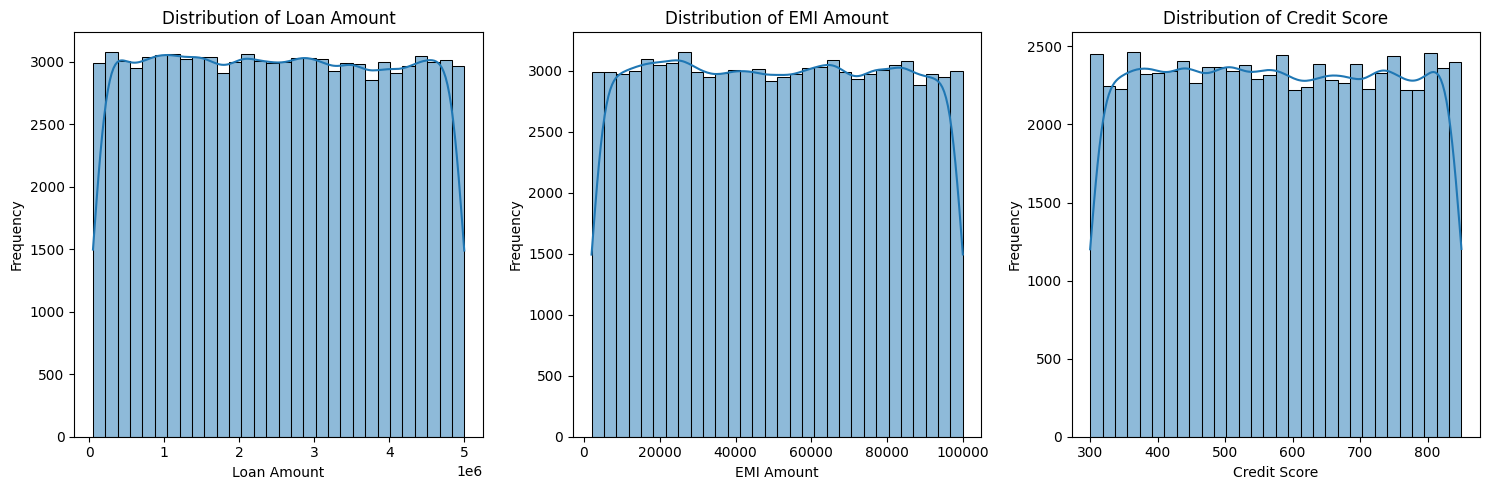

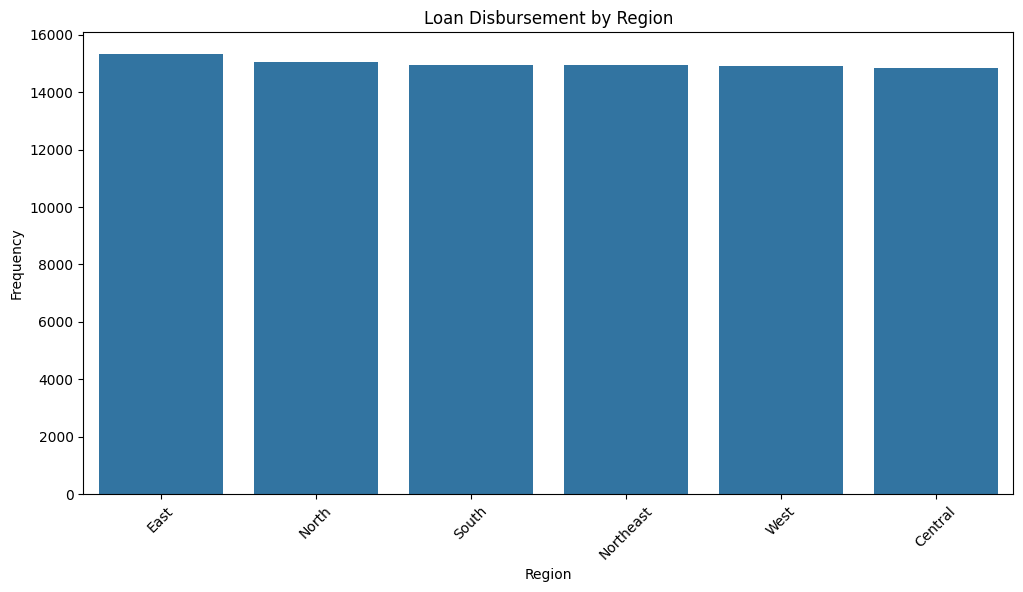

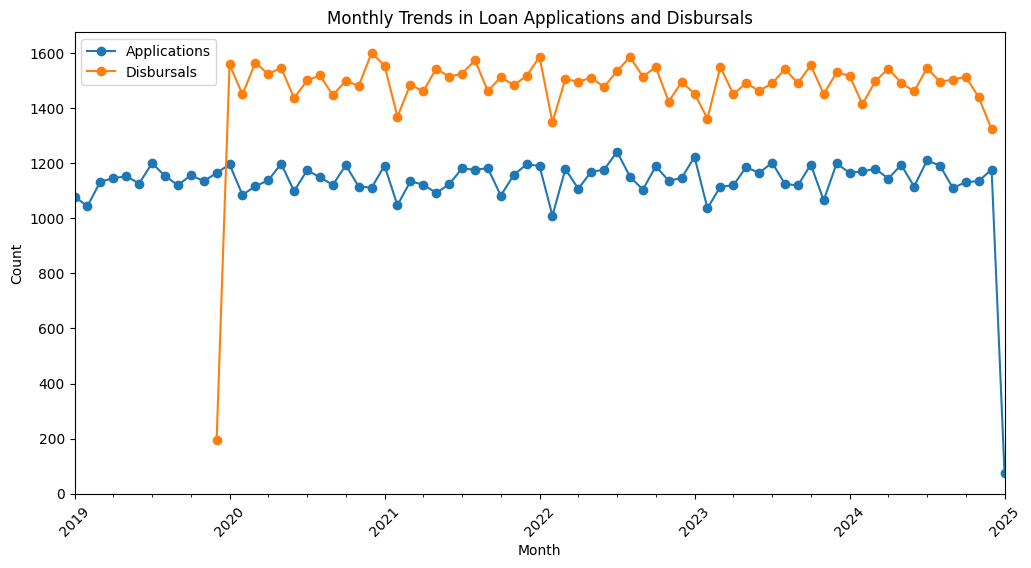

In [10]:
# Summarize and visualize key metrics:
#Distribution of Loan_Amount, EMI_Amount, and Credit_Score.
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.histplot(loans['Loan_Amount'], bins=30, kde=True)
plt.title('Distribution of Loan Amount')
plt.xlabel('Loan Amount')
plt.ylabel('Frequency')

plt.subplot(1, 3, 2)
sns.histplot(loans['EMI_Amount'], bins=30, kde=True)
plt.title('Distribution of EMI Amount')
plt.xlabel('EMI Amount')
plt.ylabel('Frequency')

plt.subplot(1, 3, 3)
sns.histplot(custs['Credit_Score'], bins=30, kde=True)
plt.title('Distribution of Credit Score')
plt.xlabel('Credit Score')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# Merge loans with custs to get Region
loans_with_region = loans.merge(custs[['Customer_ID', 'Region']], on='Customer_ID', how='left')

# regional trends in loan disbursement and defaults
plt.figure(figsize=(12, 6))
sns.countplot(data=loans_with_region, x='Region', order=loans_with_region['Region'].value_counts().index)
plt.title('Loan Disbursement by Region')
plt.xlabel('Region')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()





# Monthly trends in loan approval and disbursement
apps['Application_Month'] = apps['Application_Date'].dt.to_period('M')
loans['Disbursal_Month'] = loans['Disbursal_Date'].dt.to_period('M')
plt.figure(figsize=(12, 6))
apps['Application_Month'].value_counts().sort_index().plot(kind='line', marker='o', label='Applications')
loans['Disbursal_Month'].value_counts().sort_index().plot(kind='line', marker='o', label='Disbursals')
plt.title('Monthly Trends in Loan Applications and Disbursals')
plt.xlabel('Month')
plt.ylabel('Count')
plt.legend()
plt.xticks(rotation=45)
plt.show()

## 3. Default Risk Analysis
#### Correlation Between Loan Attributes and Defaults:
#### Calculate correlations between Loan_Amount, Interest_Rate,Credit_Score, and Default_Flag (a binary indicator for default)

In [11]:
# Calculate correlations between Loan_Amount, Interest_Rate, Credit_Score, and Default_Flag (a binary indicator for default)

# Create Default_Flag in loans (1 if defaulted, 0 otherwise)
loans['Default_Flag'] = loans['Loan_ID'].isin(defaults['Loan_ID']).astype(int)

# Merge Credit_Score from custs into loans if not present
if 'Credit_Score' not in loans.columns:
    loans = loans.merge(custs[['Customer_ID', 'Credit_Score']], on='Customer_ID', how='left')

# Select relevant columns
corr_df = loans[['Loan_Amount', 'Interest_Rate', 'Credit_Score', 'Default_Flag']]

# Compute correlation matrix
correlations = corr_df.corr()
print('Correlation matrix:')
print(correlations)



Correlation matrix:
               Loan_Amount  Interest_Rate  Credit_Score  Default_Flag
Loan_Amount       1.000000      -0.003201      0.000139     -0.003313
Interest_Rate    -0.003201       1.000000      0.002457     -0.003750
Credit_Score      0.000139       0.002457      1.000000     -0.001580
Default_Flag     -0.003313      -0.003750     -0.001580      1.000000


## ● Pairwise Correlation Analysis:
o Create a heatmap to visualize the correlations between key
variables, such as EMI_Amount, Overdue_Amount, and
Default_Amount.

Correlation matrix:
                EMI_Amount  Overdue_Amount  Default_Amount
EMI_Amount        1.000000        0.008211        0.007650
Overdue_Amount    0.008211        1.000000       -0.010207
Default_Amount    0.007650       -0.010207        1.000000


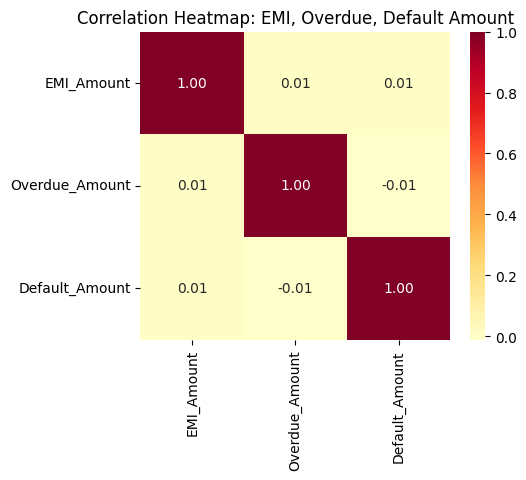

In [12]:
# o Create a heatmap to visualize the correlations between key
# variables, such as EMI_Amount, Overdue_Amount, and
# Default_Amount.


# Merge Default_Amount from defaults into loans if not present
if 'Default_Amount' not in loans.columns:
    loans = loans.merge(defaults[['Loan_ID', 'Default_Amount']], on='Loan_ID', how='left')

# Merge Overdue_Amount from defaults if present, otherwise skip
if 'Overdue_Amount' in defaults.columns and 'Overdue_Amount' not in loans.columns:
    loans = loans.merge(defaults[['Loan_ID', 'Overdue_Amount']], on='Loan_ID', how='left')

# Select relevant columns for correlation
corr_cols = ['EMI_Amount', 'Overdue_Amount', 'Default_Amount']
existing_cols = [col for col in corr_cols if col in loans.columns]

corr_df = loans[existing_cols].dropna()

# Compute correlation matrix
correlations = corr_df.corr()
print('Correlation matrix:')
print(correlations)

# Visualize correlation matrix
plt.figure(figsize=(5, 4))
sns.heatmap(correlations, annot=True, cmap='YlOrRd', fmt='.2f')
plt.title('Correlation Heatmap: EMI, Overdue, Default Amount')
plt.show()


##  Correlation Between Branch Metrics and Defaults:
#### Analyze the relationship between branch performance metrics (e.g.,
Delinquent_Loans, Loan_Disbursement_Amount) and default rates.

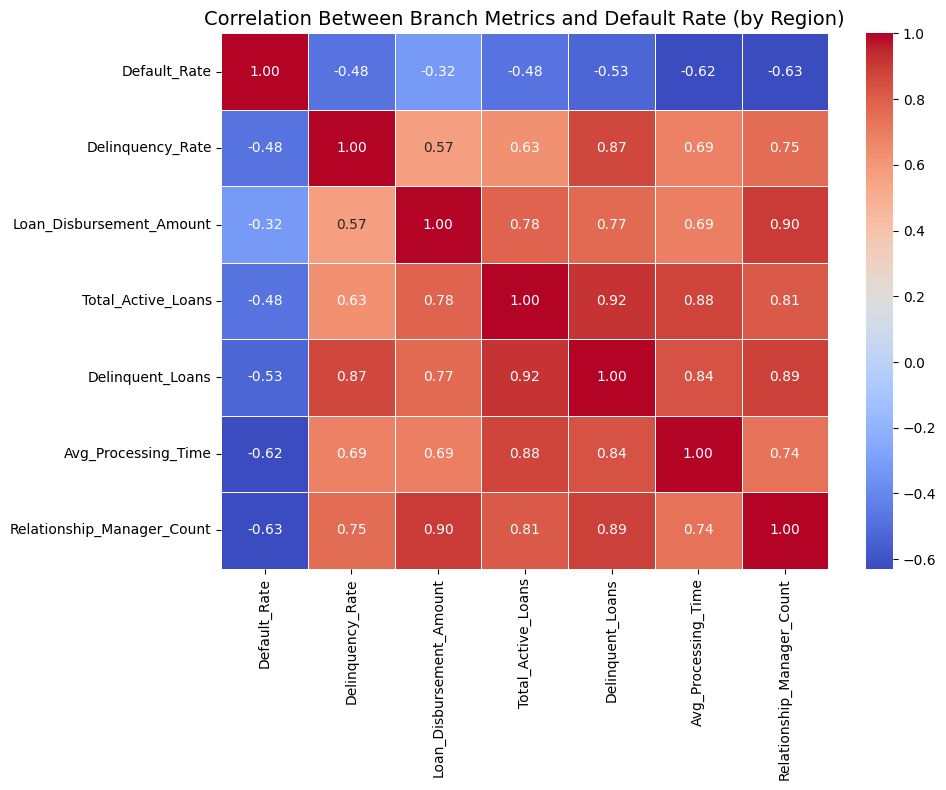

Correlation values with Default_Rate:
Loan_Disbursement_Amount     -0.322594
Delinquency_Rate             -0.479767
Total_Active_Loans           -0.481211
Delinquent_Loans             -0.532834
Avg_Processing_Time          -0.623299
Relationship_Manager_Count   -0.628675
Name: Default_Rate, dtype: float64


In [13]:
# 1. Create a default flag for each loan
defaulted_loan_ids = defaults['Loan_ID'].unique()
loans['is_default'] = loans['Loan_ID'].isin(defaulted_loan_ids).astype(int)

# 2. Merge loans with customers to get the 'Region' for each loan
loans_with_region = loans.merge(custs[['Customer_ID', 'Region']], on='Customer_ID', how='inner')

# 3. Calculate Default Rate by Region
region_defaults = loans_with_region.groupby('Region')['is_default'].agg(
    Total_Loans='count', 
    Defaulted_Loans='sum'
).reset_index()
region_defaults['Default_Rate'] = region_defaults['Defaulted_Loans'] / region_defaults['Total_Loans']

# 4. Aggregate branch metrics by Region
branch_agg = branches.groupby('Region').agg(
    Total_Active_Loans=('Total_Active_Loans', 'sum'),
    Delinquent_Loans=('Delinquent_Loans', 'sum'),
    Loan_Disbursement_Amount=('Loan_Disbursement_Amount', 'sum'),
    Avg_Processing_Time=('Avg_Processing_Time', 'mean'),
    Relationship_Manager_Count=('Relationship_Manager_Count', 'sum')
).reset_index()

# Calculate a Branch Delinquency Rate metric
branch_agg['Delinquency_Rate'] = branch_agg['Delinquent_Loans'] / branch_agg['Total_Active_Loans']

# 5. Merge Regional Default Rate with Branch Metrics
branch_metrics_vs_defaults = region_defaults.merge(branch_agg, on='Region', how='inner')

# 6. Perform Correlation Analysis
correlation_cols = [
    'Default_Rate', 'Delinquency_Rate', 'Loan_Disbursement_Amount', 
    'Total_Active_Loans', 'Delinquent_Loans', 'Avg_Processing_Time', 'Relationship_Manager_Count'
]
correlation_matrix = branch_metrics_vs_defaults[correlation_cols].corr()

# 7. Visualize the Correlation Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Between Branch Metrics and Default Rate (by Region)', fontsize=14)
plt.tight_layout()
plt.show()

# 8. Display direct correlations with 'Default_Rate'
print("Correlation values with Default_Rate:")
print(correlation_matrix['Default_Rate'].sort_values(ascending=False).drop('Default_Rate'))


 # 4. Branch and Regional Performance
● Rank branches by:
o Loan disbursement volume.
o Processing time efficiency.
o Default rates and recovery rates.
● Compare branch performance across regions.

In [39]:
# rank branches by:
# 1. Loan Disbursement volume
branch_rank = branches.sort_values(by='Loan_Disbursement_Amount', ascending=False).reset_index(drop=True)

# Merge regional default rate and recovery rate into branch_rank
branch_rank = branch_rank.merge(region_defaults[['Region', 'Default_Rate']], on='Region', how='left')
branch_rank = branch_rank.merge(region_recovery[['Region', 'Recovery_Rate']], on='Region', how='left')

# 2. Processing time efficiency
branch_rank['Processing_Time_Rank'] = branch_rank['Avg_Processing_Time'].rank(ascending=True)

# 3. Default rates and recovery rates
branch_rank['Default_Rate_Rank'] = branch_rank['Default_Rate'].rank(ascending=False)
branch_rank['Recovery_Rate_Rank'] = branch_rank['Recovery_Rate'].rank(ascending=True)





- Compare branch performance across regions.

C:\Users\DELL\AppData\Local\Temp\ipykernel_16484\778843292.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




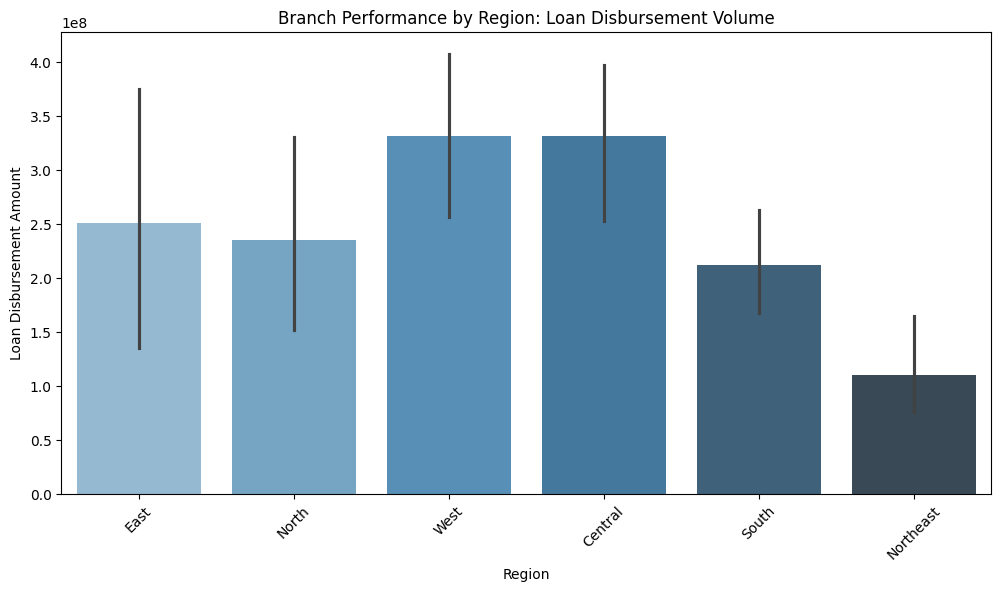

In [40]:
# compare branch performance across regions
plt.figure(figsize=(12, 6))
sns.barplot(data=branch_rank, x='Region', y='Loan_Disbursement_Amount', palette='Blues_d')
plt.title('Branch Performance by Region: Loan Disbursement Volume')
plt.xlabel('Region')
plt.ylabel('Loan Disbursement Amount')
plt.xticks(rotation=45)
plt.show()


Top 5 Branches by Disbursement Volume:
                     Branch_Name   Region  Loan_Disbursement_Amount
35                     Kara-Bahl     East                 499562869
13           Bhatti, Rau and Sem    North                 482327541
11                      Kaul Inc     West                 465469874
47            Chawla-Subramanian  Central                 464419943
34  Malhotra, Boase and Malhotra  Central                 449109596

Most Efficient Branches (Lowest Processing Time):
                   Branch_Name     Region  Avg_Processing_Time
49                   Sani-Kale      North                    1
46               Chawla-Tandon       East                    2
41                   Kar-Jaggi       West                    2
17  Sandhu, Magar and Sachdeva  Northeast                    2
44                Solanki-Shah      South                    3

Regional Performance Comparison:
           Loan_Disbursement_Amount  Avg_Processing_Time  Delinquency_Rate
Region         

C:\Users\DELL\AppData\Local\Temp\ipykernel_16484\1710908639.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=regional_perf.index, y='Loan_Disbursement_Amount', data=regional_perf, ax=ax1, palette='Blues_d')


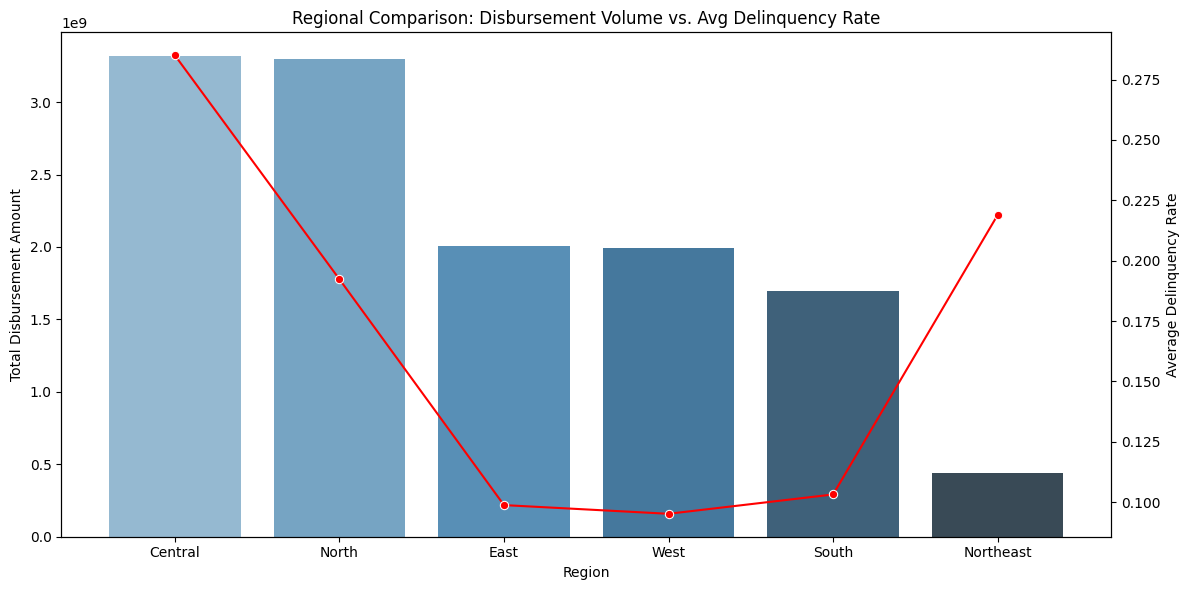

In [15]:
# --- Branch and Regional Performance Analysis ---

# 1. Calculate Per-Branch Default and Recovery Rates
# Since 'branches' has Delinquent_Loans, we calculate 'Delinquency Rate'
branches['Delinquency_Rate'] = branches['Delinquent_Loans'] / branches['Total_Active_Loans']

# To get Recovery Rates, we need to handle the Defaults data (Recovery_Amount / Default_Amount)
# Note: Recovery rates are typically calculated at the loan level and then aggregated if a mapping exists.
# If no mapping to Branch_ID exists in defaults, we provide the logic to calculate top-level recovery first.
recovery_by_loan = defaults.groupby('Loan_ID').agg({'Recovery_Amount':'sum', 'Default_Amount':'first'}).reset_index()
recovery_by_loan['Recovery_Rate'] = (recovery_by_loan['Recovery_Amount'] / recovery_by_loan['Default_Amount']).fillna(0)

# 2. Ranking Branches
# Rank by Loan Disbursement Volume (Highest to Lowest)
top_disbursement = branches[['Branch_Name', 'Region', 'Loan_Disbursement_Amount']].sort_values(by='Loan_Disbursement_Amount', ascending=False)

# Rank by Processing Time Efficiency (Lowest Time is better efficiency)
top_efficiency = branches[['Branch_Name', 'Region', 'Avg_Processing_Time']].sort_values(by='Avg_Processing_Time', ascending=True)

# Rank by Delinquency Rate (Lowest Rate is better performance)
top_safety = branches[['Branch_Name', 'Region', 'Delinquency_Rate']].sort_values(by='Delinquency_Rate', ascending=True)

print("Top 5 Branches by Disbursement Volume:")
print(top_disbursement.head())
print("\nMost Efficient Branches (Lowest Processing Time):")
print(top_efficiency.head())

# 3. Regional Comparison
regional_perf = branches.groupby('Region').agg({
    'Loan_Disbursement_Amount': 'sum',
    'Avg_Processing_Time': 'mean',
    'Delinquency_Rate': 'mean'
}).sort_values(by='Loan_Disbursement_Amount', ascending=False)

print("\nRegional Performance Comparison:")
print(regional_perf)

# 4. Visualization: Regional Distribution of Disbursement and Delinquency
fig, ax1 = plt.subplots(figsize=(12, 6))

sns.barplot(x=regional_perf.index, y='Loan_Disbursement_Amount', data=regional_perf, ax=ax1, palette='Blues_d')
ax1.set_ylabel('Total Disbursement Amount')
ax1.set_title('Regional Comparison: Disbursement Volume vs. Avg Delinquency Rate')

ax2 = ax1.twinx()
sns.lineplot(x=regional_perf.index, y='Delinquency_Rate', data=regional_perf, ax=ax2, color='red', marker='o')
ax2.set_ylabel('Average Delinquency Rate')

plt.tight_layout()
plt.show()


# 5. Customer Segmentation
● Segment customers by income, credit score, and loan status.
● Identify high-risk and high-value customer groups.
● Analyze repayment behavior across segments.

In [41]:
# segment customer by income, credit score, and loan status
# Create income segments
custs['Income_Segment'] = pd.qcut(custs['Annual_Income'], q=4, labels=['Low', 'Medium', 'High', 'Very High'])
# Create credit score segments
custs['Credit_Score_Segment'] = pd.qcut(custs['Credit_Score'], q=4, labels=['Poor', 'Fair', 'Good', 'Excellent'])
# Create loan status segments
loans['Loan_Status'] = np.where(loans['Loan_ID'].isin(defaults['Loan_ID']), 'Defaulted', 'Current')


In [42]:
# Identify high-risk and high-value customers groups.
# High-risk: Low Income, Poor Credit Score, Defaulted
high_risk_customers = custs[
    (custs['Income_Segment'] == 'Low') & 
    (custs['Credit_Score_Segment'] == 'Poor') & 
    (loans['Loan_Status'] == 'Defaulted')
]
print("High-Risk Customers:")
print(high_risk_customers.head())


C:\Users\DELL\AppData\Local\Temp\ipykernel_16484\3627940863.py:3: UserWarning:

Boolean Series key will be reindexed to match DataFrame index.



High-Risk Customers:
    Customer_ID        Full_Name  Contact_Number  \
18      C000019    Gatik Kashyap      4950664352   
409     C000410  Divyansh Sahota    919918845952   
413     C000414     Reyansh Bhat      1191380853   
439     C000440      Adah Varkey      5307234112   
491     C000492        Rati Sood      3661915074   

                            Email                                 Address  \
18             armaan51@yahoo.com   75/509\nVaidya Road, Amaravati-807304   
409         alishawason@gmail.com     97/87, Wable Marg, Berhampur-270292   
413  chadhadhanush@kade-bassi.com            090\nBail Ganj, Kulti 174605   
439     wramachandran@hotmail.com   H.No. 280\nSolanki, Coimbatore 977500   
491          echerian@hotmail.com  H.No. 311\nManda Zila, Bhiwandi-180400   

     Age  Gender Marital_Status Employment_Status  Annual_Income  \
18    67    Male         Single     Self-Employed         339216   
409   55   Other         Single          Salaried         325653   

In [49]:
# Analyze repayments behavior across segments
repayment_behavior = loans.merge(custs[['Customer_ID', 'Income_Segment', 'Credit_Score_Segment']], on='Customer_ID', how='left')
repayment_behavior = repayment_behavior.merge(defaults[['Loan_ID', 'Default_Amount']], on='Loan_ID', how='left')
repayment_behavior

,Loan_ID,Customer_ID,Loan_Amount,Interest_Rate,Loan_Term,Disbursal_Date,Repayment_Start_Date,Repayment_End_Date,Loan_Status,Overdue_Amount,...,Default_Flag,Credit_Score,Default_Amount_x,is_default,EMI_Range,Interest_Income,Disbursal_Month_Year,Income_Segment,Credit_Score_Segment,Default_Amount_y
0,L000001,C045929,4030468,8.45,24,2023-03-25,2023-04-25,2025-03-25,Current,0,...,0,343,NaN,0,1,-3582436,2023-03,Low,Poor,NaN
1,L000002,C038991,3498647,11.90,48,2023-10-23,2023-11-23,2027-10-23,Current,44003,...,0,589,NaN,0,3,-1770071,2023-10,Medium,Good,NaN
2,L000003,C046662,4871438,9.74,24,2024-07-30,2024-08-30,2026-07-30,Current,0,...,0,832,NaN,0,2,-4239110,2024-07,Low,Excellent,NaN
3,L000004,C040268,541515,13.55,24,2024-11-22,2024-12-22,2026-11-22,Current,0,...,0,517,NaN,0,1,-154971,2024-11,Very High,Fair,NaN
4,L000005,C067057,631036,10.10,36,2024-03-30,2024-04-30,2027-03-30,Current,0,...,0,481,NaN,0,0,-266464,2024-03,Low,Fair,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91412,L089996,C062366,4932615,12.68,36,2023-03-04,2023-04-04,2026-03-04,Current,0,...,0,417,NaN,0,9,-1424847,2023-03,Medium,Poor,NaN
91413,L089997,C010516,4493121,11.98,48,2022-11-02,2022-12-02,2026-11-02,Current,0,...,0,398,NaN,0,9,289023,2022-11,Low,Poor,NaN
91414,L089998,C052676,4107372,13.26,48,2024-11-26,2024-12-26,2028-11-26,Current,24135,...,0,558,NaN,0,4,-2046924,2024-11,Low,Fair,NaN
91415,L089999,C068124,100576,8.69,12,2024-12-23,2025-01-23,2025-12-23,Defaulted,1262,...,1,745,98012.0,1,0,-60136,2024-12,High,Excellent,98012.0


Total High-Value Customers identified: 16480
Total High-Risk Customers identified: 63133

Repayment Behavior Analysis by Segment:
  Income_Segment Credit_Segment   Loan_Amount  Customer_Count
0    High Income      Excellent  2.524183e+06           16480
1    High Income           Good  2.502702e+06           24378
2    High Income           Poor  2.521004e+06           49603


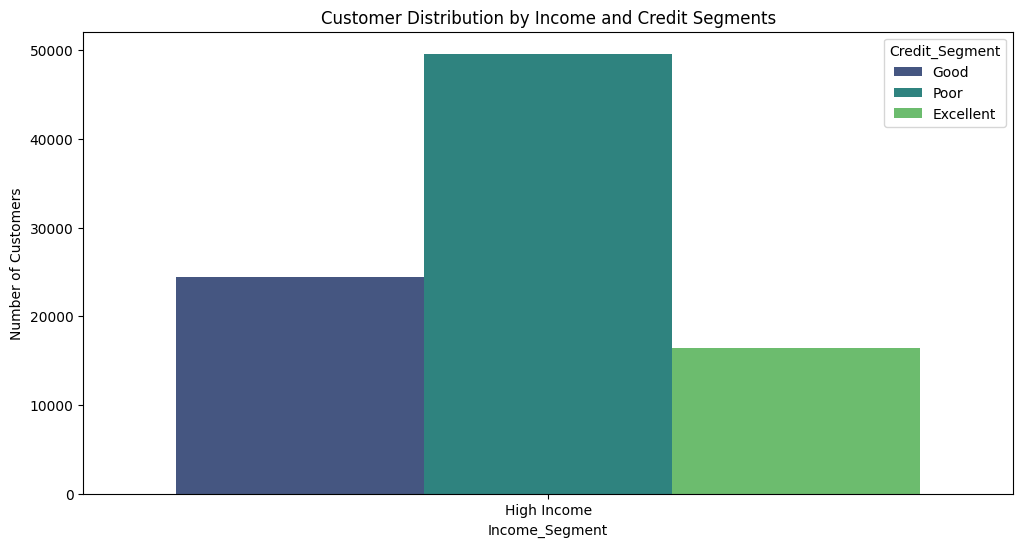

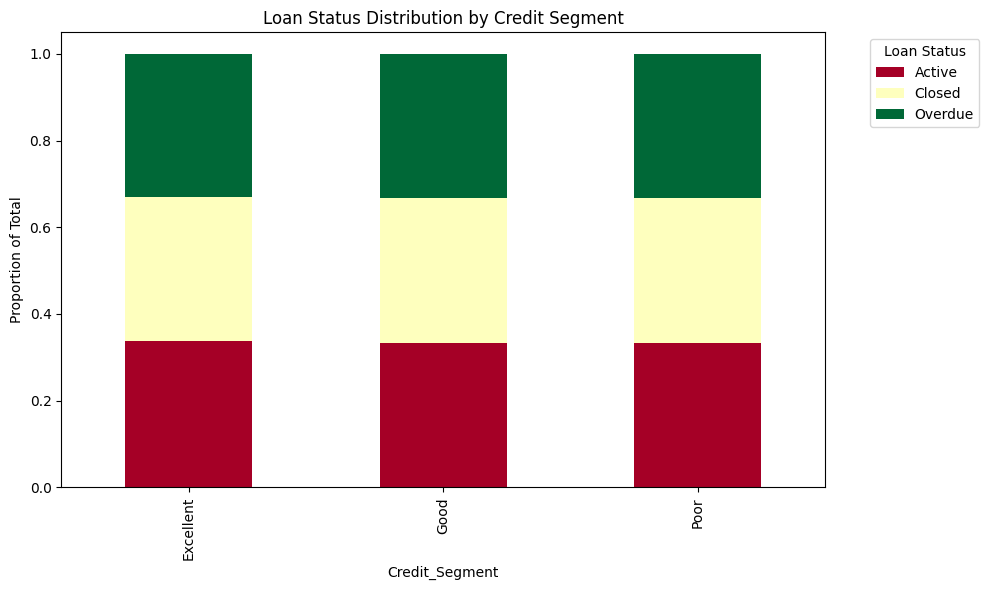

In [16]:
# --- Customer Segmentation Analysis ---

# 1. Segmenting by Income and Credit Score
# Define Income Segments
def get_income_segment(income):
    if income < 30000: return 'Low Income'
    elif income < 70000: return 'Middle Income'
    else: return 'High Income'

custs['Income_Segment'] = custs['Annual_Income'].apply(get_income_segment)

# Define Credit Score Segments
def get_credit_segment(score):
    if score < 600: return 'Poor'
    elif score < 750: return 'Good'
    else: return 'Excellent'

custs['Credit_Segment'] = custs['Credit_Score'].apply(get_credit_segment)

# 2. Merge with Loan Data to Identify High-Value and High-Risk Groups
# High Value: High Income + Excellent Credit Score
# High Risk: Low Credit Score + Defaulted Status
customer_loan_data = custs.merge(loans[['Customer_ID', 'Loan_Status', 'Loan_Amount']], on='Customer_ID', how='inner')

# Identify High-Value Customers
high_value = customer_loan_data[(customer_loan_data['Income_Segment'] == 'High Income') & 
                                (customer_loan_data['Credit_Segment'] == 'Excellent')]

# Identify High-Risk Customers
high_risk = customer_loan_data[(customer_loan_data['Credit_Segment'] == 'Poor') | 
                               (customer_loan_data['Loan_Status'] == 'Overdue')]

print(f"Total High-Value Customers identified: {len(high_value)}")
print(f"Total High-Risk Customers identified: {len(high_risk)}")

# 3. Analyze Repayment Behavior Across Segments
# We define repayment behavior by checking the mean Loan Amount and typical status distribution per segment
segment_analysis = customer_loan_data.groupby(['Income_Segment', 'Credit_Segment']).agg({
    'Loan_Amount': 'mean',
    'Customer_ID': 'count'
}).rename(columns={'Customer_ID': 'Customer_Count'}).reset_index()

print("\nRepayment Behavior Analysis by Segment:")
print(segment_analysis)

# 4. Visualization: Customer Distribution by Segments
plt.figure(figsize=(12, 6))
sns.countplot(x='Income_Segment', hue='Credit_Segment', data=customer_loan_data, palette='viridis')
plt.title('Customer Distribution by Income and Credit Segments')
plt.ylabel('Number of Customers')
plt.show()

# 5. Relationship between Segments and Loan Status
status_pivot = pd.crosstab(customer_loan_data['Credit_Segment'], customer_loan_data['Loan_Status'], normalize='index')
status_pivot.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='RdYlGn')
plt.title('Loan Status Distribution by Credit Segment')
plt.ylabel('Proportion of Total')
plt.legend(title='Loan Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()



## 6. Advanced Statistical Analysis
1. Correlation Analysis for Default Risks:
o Examine the correlation between Credit_Score, Loan_Amount,
Interest_Rate, Overdue_Amount, and Default_Flag.
2. Pairwise Correlation Heatmap:
o Generate a heatmap to visualize correlations among key variables
like EMI_Amount, Recovery_Rate, and Default_Amount.
3. Branch-Level Correlation:
o Explore the relationship between branch performance metrics
(Delinquent_Loans, Loan_Disbursement_Amount, Recovery_Rate)
and overall efficiency.


In [53]:
# correlation between Credit Score, Loan Amount, Interest Rate, Overdue Amount, and Default Amount
# Select relevant columns for correlation
corr_cols = ['Credit_Score', 'Loan_Amount', 'Interest_Rate', 'Overdue_Amount', 'Default_Amount']
corr_df = loans.merge(custs[['Customer_ID', 'Credit_Score']], on='Customer_ID', how='left')
corr_df = corr_df[[c for c in corr_cols if c in corr_df.columns]]
corr_df = corr_df.apply(pd.to_numeric, errors='coerce')
correlation_matrix = corr_df.corr()

print('Correlation matrix:')
print(correlation_matrix)



Correlation matrix:
                Loan_Amount  Interest_Rate  Overdue_Amount  Default_Amount
Loan_Amount        1.000000      -0.003451        0.008249       -0.017102
Interest_Rate     -0.003451       1.000000       -0.002700        0.006651
Overdue_Amount     0.008249      -0.002700        1.000000       -0.010207
Default_Amount    -0.017102       0.006651       -0.010207        1.000000


In [ ]:
# # --- 6. Advanced Statistical Analysis (FIXED) ---

# # 1. Create Default_Flag in loans
# default_ids = defaults['Loan_ID'].unique()
# loans['Default_Flag'] = loans['Loan_ID'].isin(default_ids).astype(int)

# # 2. Merge Credit_Score and Region from customers into loans
# # We use suffixes to prevent confusion if columns exist in both
# loans_merged = loans.merge(custs[['Customer_ID', 'Credit_Score', 'Region']], on='Customer_ID', how='inner')

# # 3. Calculate Recovery_Rate in the defaults table
# defaults['Recovery_Rate'] = (defaults['Recovery_Amount'] / defaults['Default_Amount']).fillna(0)

# # 4. Merge Recovery info into the main analysis dataframe
# # We explicitly select 'Loan_ID' and 'Default_Amount' from the defaults table
# analysis_df = loans_merged.merge(
#     defaults[['Loan_ID', 'Recovery_Rate', 'Default_Amount']], 
#     on='Loan_ID', 
#     how='left'
# )

# # 5. Fill NaN values for non-defaulted loans (they have 0 recovery and 0 default amount)
# analysis_df['Recovery_Rate'] = analysis_df['Recovery_Rate'].fillna(0)
# # Use a safe way to check if Default_Amount exists (it might have a suffix if 'loans' also had it)
# if 'Default_Amount_y' in analysis_df.columns:
#     analysis_df['Default_Amount'] = analysis_df['Default_Amount_y'].fillna(0)
# elif 'Default_Amount' in analysis_df.columns:
#     analysis_df['Default_Amount'] = analysis_df['Default_Amount'].fillna(0)
# else:
#     # If it's completely missing from defaults for some reason, we initialize as 0
#     analysis_df['Default_Amount'] = 0

# # --- 6.1 Correlation Analysis for Default Risks ---
# risk_cols = ['Credit_Score', 'Loan_Amount', 'Interest_Rate', 'Overdue_Amount', 'Default_Flag']
# # Filter existing columns only to be safe
# risk_cols = [c for c in risk_cols if c in analysis_df.columns]
# risk_correlation = analysis_df[risk_cols].corr()

# print("Correlation with Default_Flag:")
# print(risk_correlation['Default_Flag'].sort_values(ascending=False))



Correlation with Default_Flag:
Default_Flag      1.000000
Overdue_Amount    0.001031
Loan_Amount      -0.000484
Interest_Rate    -0.006374
Name: Default_Flag, dtype: float64


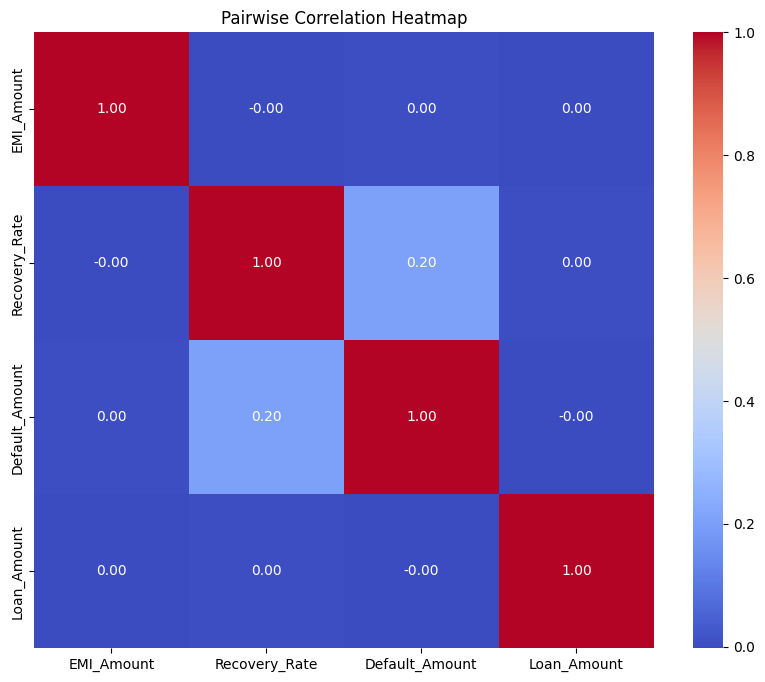

In [54]:
# --- 6.2 Pairwise Correlation Heatmap ---
plt.figure(figsize=(10, 8))
key_vars = ['EMI_Amount', 'Recovery_Rate', 'Default_Amount', 'Loan_Amount', 'Credit_Score']
key_vars = [v for v in key_vars if v in analysis_df.columns]
sns.heatmap(analysis_df[key_vars].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Pairwise Correlation Heatmap')
plt.show()



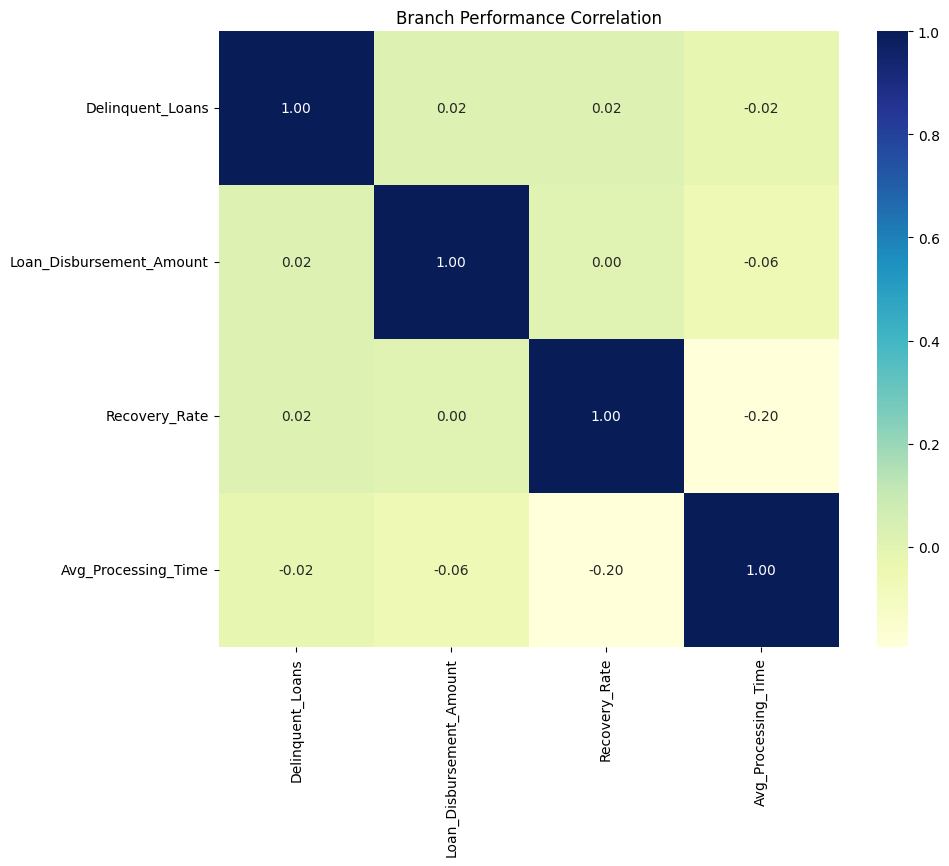

In [55]:
# --- 6.3 Branch-Level Correlation ---
region_recovery = analysis_df.groupby('Region')['Recovery_Rate'].mean().reset_index()
branch_stats = branches.merge(region_recovery, on='Region', how='inner')

branch_corr_cols = ['Delinquent_Loans', 'Loan_Disbursement_Amount', 'Recovery_Rate', 'Avg_Processing_Time']
branch_correlation = branch_stats[branch_corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(branch_correlation, annot=True, cmap='YlGnBu', fmt=".2f")
plt.title('Branch Performance Correlation')
plt.show()

# 7. Transaction and Recovery Analysis
● Analyze penalty payments and overdue trends.
● Evaluate recovery rates by Default_Reason and Legal_Action.
● Compare recovery rates across regions and branches.


Average Recovery Rate by Default Reason:
Default_Reason
Medical Emergency    0.417939
Job Loss             0.406174
Business Failure     0.403627
Other                0.390761
Name: Recovery_Rate, dtype: float64

Average Recovery Rate by Legal Action Status:
Legal_Action
No     0.401805
Yes    0.407372
Name: Recovery_Rate, dtype: float64


C:\Users\DELL\AppData\Local\Temp\ipykernel_16484\69291436.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=reason_recovery.index, y=reason_recovery.values, ax=ax1, palette='mako')
C:\Users\DELL\AppData\Local\Temp\ipykernel_16484\69291436.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=legal_recovery.index, y=legal_recovery.values, ax=ax2, palette='viridis')


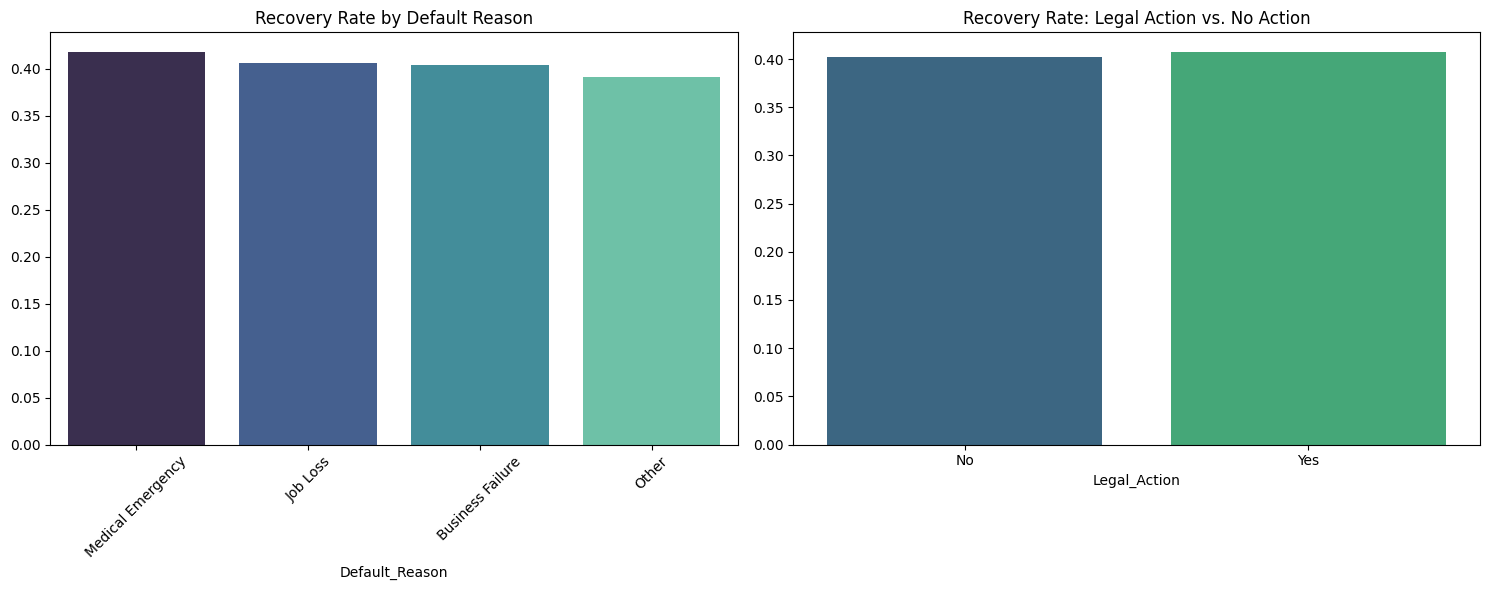


--- Average Recovery Rate by Region ---
Region
Central      0.447717
Northeast    0.411552
South        0.409559
North        0.382243
West         0.374519
East         0.357711
Name: Recovery_Rate, dtype: float64


C:\Users\DELL\AppData\Local\Temp\ipykernel_16484\69291436.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Region', y='Recovery_Rate', data=defaults_with_region, palette='Set2')


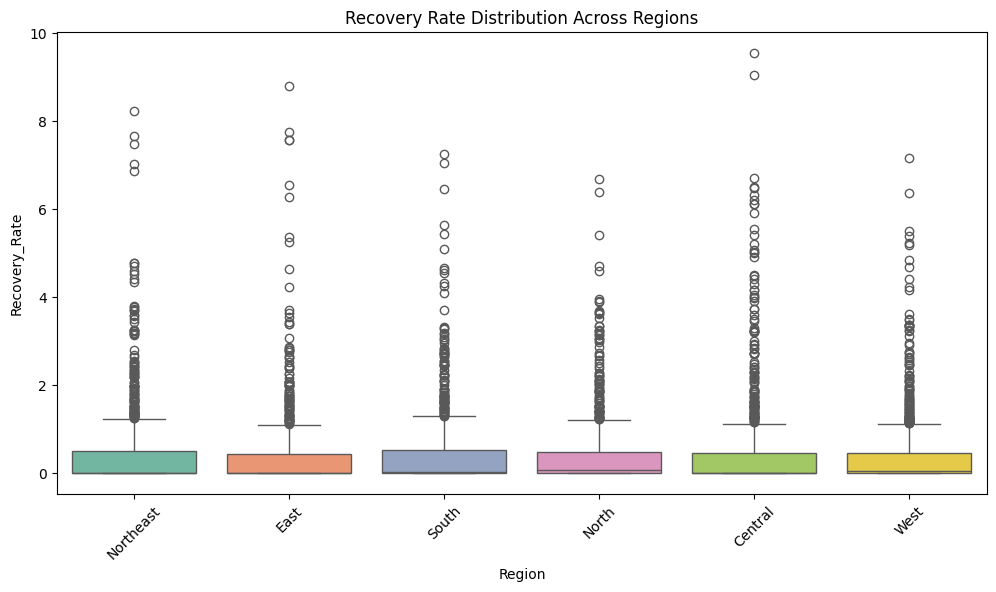

In [20]:

# --- 7. Transaction and Recovery Analysis ---

# 1. Analyze penalty payments and overdue trends
# Penalty data is usually in the transactions table (Late_Fee or similar)
# I assume 'trans' has Transaction_Type or Penalty_Amount columns.
if 'Late_Fee' in trans.columns:
    late_fee_summary = trans.groupby(trans['Transaction_Date'].dt.to_period('M'))['Late_Fee'].sum()
    late_fee_summary.plot(kind='line', figsize=(10, 5), title='Monthly Penalty (Late Fee) Collection Trend')
    plt.ylabel('Total Late Fees Collected')
    plt.show()

# 2. Evaluate recovery rates by Default_Reason and Legal_Action
# Ensure Recovery_Rate is calculated in 'defaults'
defaults['Recovery_Rate'] = (defaults['Recovery_Amount'] / defaults['Default_Amount']).fillna(0)

# Recovery rate by Reason
reason_recovery = defaults.groupby('Default_Reason')['Recovery_Rate'].mean().sort_values(ascending=False)
print("Average Recovery Rate by Default Reason:")
print(reason_recovery)

# Recovery rate by Legal Action
legal_recovery = defaults.groupby('Legal_Action')['Recovery_Rate'].mean()
print("\nAverage Recovery Rate by Legal Action Status:")
print(legal_recovery)

# # Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(x=reason_recovery.index, y=reason_recovery.values, ax=ax1, palette='mako')
ax1.set_title('Recovery Rate by Default Reason')
ax1.tick_params(axis='x', rotation=45)

sns.barplot(x=legal_recovery.index, y=legal_recovery.values, ax=ax2, palette='viridis')
ax2.set_title('Recovery Rate: Legal Action vs. No Action')

plt.tight_layout()
plt.show()

# 3. Compare recovery rates across Regions and branches


# Step 1: Merge defaults with customers to get Region
defaults_with_region = defaults.merge(custs[['Customer_ID', 'Region']], on='Customer_ID', how='inner')

# Calculate the average recovery rate by Region
regional_recovery = defaults_with_region.groupby('Region')['Recovery_Rate'].mean().sort_values(ascending=False)

print("\n--- Average Recovery Rate by Region ---")
print(regional_recovery)

# Note: Branch-level analysis is not possible without 'Branch_ID' in 'loans' or 'defaults'. Using Region as proxy.

# Visualizing Recovery Rate by Region
plt.figure(figsize=(12, 6))
sns.boxplot(x='Region', y='Recovery_Rate', data=defaults_with_region, palette='Set2')
plt.title('Recovery Rate Distribution Across Regions')
plt.xticks(rotation=45)
plt.show()



# 8. EMI Analysis
● Analyze the relationship between EMI amounts and default probabilities.
● Identify thresholds for EMI amounts where defaults are most likely.
● Compare EMI trends across loan types

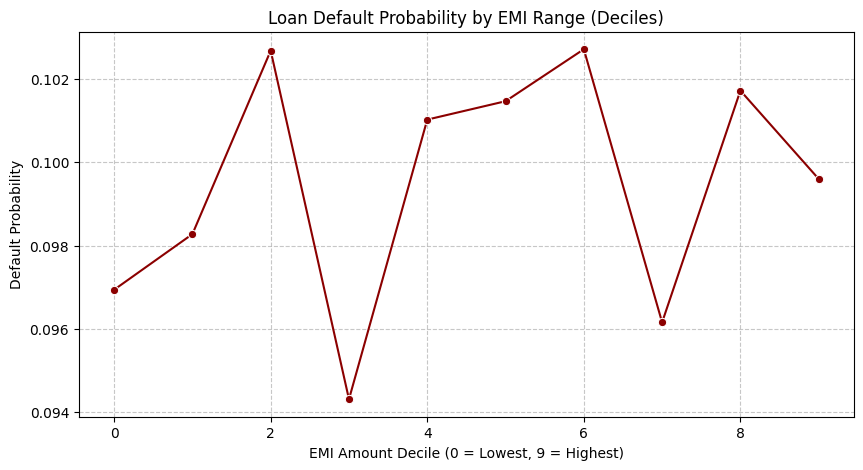

C:\Users\DELL\AppData\Local\Temp\ipykernel_16484\808901047.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Default_Flag', y='EMI_Amount', data=loans, palette='Set1')


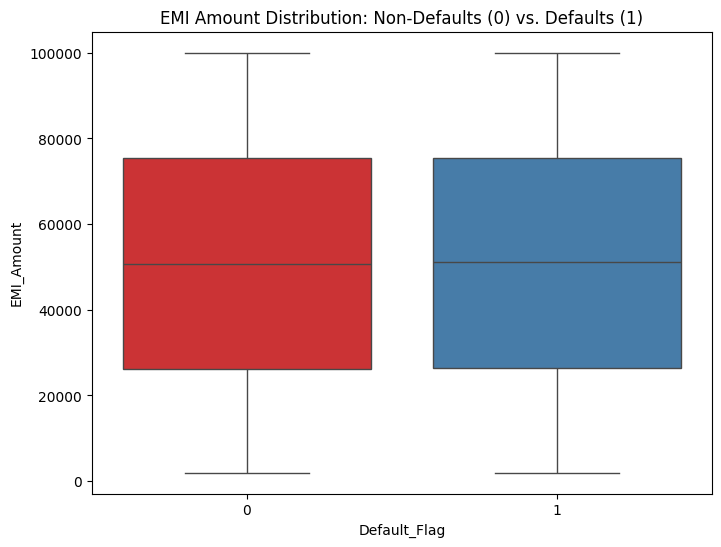

Median EMI for Non-Defaulters: 50779.0
Median EMI for Defaulters: 51200.0

Observation: Defaulters typically have a median EMI starting around 51200.00


C:\Users\DELL\AppData\Local\Temp\ipykernel_16484\808901047.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Loan_Purpose', y='EMI_Amount', data=loan_emi_type, palette='magma', errorbar=None)


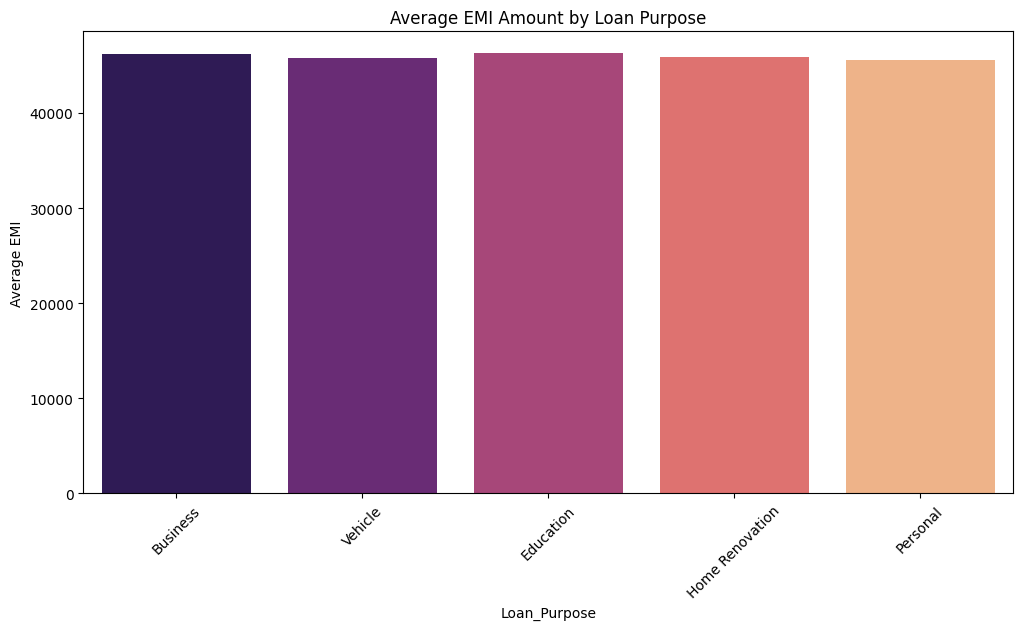


Risk Level (Default Rate) by Loan Purpose:
Loan_Purpose
Personal           0.085673
Vehicle            0.085054
Education          0.084924
Home Renovation    0.084612
Business           0.082474
Name: Default_Flag, dtype: float64


In [21]:
# --- 8. EMI Analysis ---

# 1. Analyze the relationship between EMI amounts and default probabilities
# First, ensure Default_Flag exists (1 for default, 0 otherwise)
default_loan_ids = defaults['Loan_ID'].unique()
loans['Default_Flag'] = loans['Loan_ID'].isin(default_loan_ids).astype(int)

# Create EMI Bins to calculate default probability for different EMI ranges
loans['EMI_Range'] = pd.qcut(loans['EMI_Amount'], q=10, labels=False, duplicates='drop') # 10 deciles of EMI

# Calculate default probability per EMI Range
emi_default_prob = loans.groupby('EMI_Range')['Default_Flag'].mean()

# Plot Default Probability vs. EMI Range
plt.figure(figsize=(10, 5))
sns.lineplot(x=emi_default_prob.index, y=emi_default_prob.values, marker='o', color='darkred')
plt.title('Loan Default Probability by EMI Range (Deciles)')
plt.xlabel('EMI Amount Decile (0 = Lowest, 9 = Highest)')
plt.ylabel('Default Probability')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 2. Identify thresholds for EMI amounts where defaults are most likely
# Let's use a boxplot to see the distribution of EMI for Defaults vs. Non-Defaults
plt.figure(figsize=(8, 6))
sns.boxplot(x='Default_Flag', y='EMI_Amount', data=loans, palette='Set1')
plt.title('EMI Amount Distribution: Non-Defaults (0) vs. Defaults (1)')
plt.show()

# Calculate median EMI for both groups
medians = loans.groupby('Default_Flag')['EMI_Amount'].median()
print("Median EMI for Non-Defaulters:", medians[0])
print("Median EMI for Defaulters:", medians[1])
print(f"\nObservation: Defaulters typically have a median EMI starting around {medians[1]:.2f}")

# 3. Compare EMI trends across Loan Purposes (Loan Types)
# 'applications' usually contains Loan_Purpose. Merge it into 'loans'.
# Note: Assuming Loan_ID is the common key.
loan_emi_type = loans.merge(apps[['Loan_ID', 'Loan_Purpose']], on='Loan_ID', how='inner')

plt.figure(figsize=(12, 6))
sns.barplot(x='Loan_Purpose', y='EMI_Amount', data=loan_emi_type, palette='magma', errorbar=None)
plt.title('Average EMI Amount by Loan Purpose')
plt.xticks(rotation=45)
plt.ylabel('Average EMI')
plt.show()

# Default Probability by Loan Purpose
purpose_risk = loan_emi_type.groupby('Loan_Purpose')['Default_Flag'].mean().sort_values(ascending=False)
print("\nRisk Level (Default Rate) by Loan Purpose:")
print(purpose_risk)

# 9. Loan Application Insights
● Calculate approval and rejection rates for loan applications.
● Identify the most common reasons for loan rejection.
● Compare application processing fees between approved and rejected
applications.


Total Applications: 82600
Approval Rate: 84.75%
Rejection Rate: 15.25%


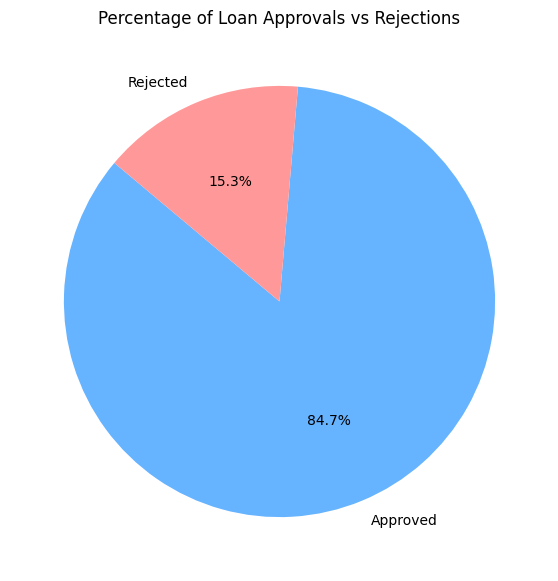


Most Common Reasons for Loan Rejection:
Rejection_Reason
Low Credit Score        4297
Incomplete Documents    4204
Insufficient Income     4099
Name: count, dtype: int64


C:\Users\DELL\AppData\Local\Temp\ipykernel_16484\4009355855.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=common_rejection_reasons.values, y=common_rejection_reasons.index, palette='Reds_r')


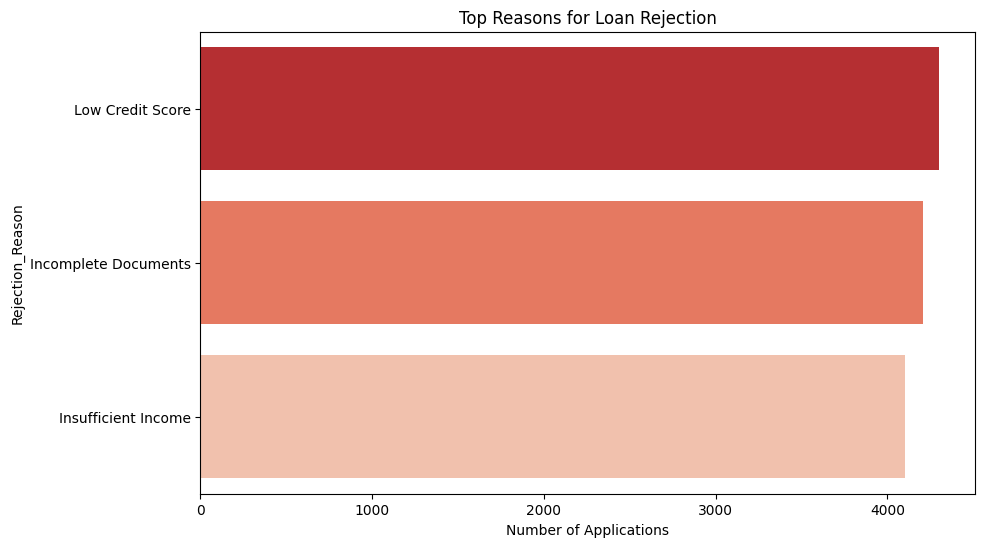


Processing Fee Statistics by Application Status:
                        mean  median          std
Approval_Status                                  
Approved         5252.395014  5256.0  2741.573413
Rejected         5255.141587  5271.0  2721.010522


C:\Users\DELL\AppData\Local\Temp\ipykernel_16484\4009355855.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Approval_Status', y='Processing_Fee', data=apps, palette='coolwarm')


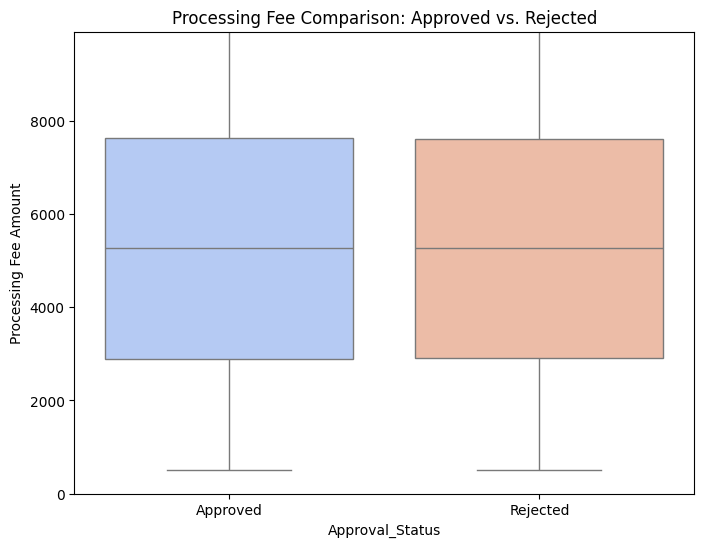

In [22]:
# --- 9. Loan Application Insights ---

# 1. Calculate approval and rejection rates for loan applications
# Status counts in the applications table
app_status_counts = apps['Approval_Status'].value_counts()
approval_rate = (app_status_counts.get('Approved', 0) / len(apps)) * 100
rejection_rate = (app_status_counts.get('Rejected', 0) / len(apps)) * 100

print(f"Total Applications: {len(apps)}")
print(f"Approval Rate: {approval_rate:.2f}%")
print(f"Rejection Rate: {rejection_rate:.2f}%")

# Visualize the status split
plt.figure(figsize=(7, 7))
plt.pie(app_status_counts, labels=app_status_counts.index, autopct='%1.1f%%', colors=['#66b3ff','#ff9999'], startangle=140)
plt.title('Percentage of Loan Approvals vs Rejections')
plt.show()

# 2. Identify the most common reasons for loan rejection
rejections = apps[apps['Approval_Status'] == 'Rejected']
common_rejection_reasons = rejections['Rejection_Reason'].value_counts().head(10)

print("\nMost Common Reasons for Loan Rejection:")
print(common_rejection_reasons)

plt.figure(figsize=(10, 6))
sns.barplot(x=common_rejection_reasons.values, y=common_rejection_reasons.index, palette='Reds_r')
plt.title('Top Reasons for Loan Rejection')
plt.xlabel('Number of Applications')
plt.show()

# 3. Compare application processing fees between approved and rejected applications
fee_comparison = apps.groupby('Approval_Status')['Processing_Fee'].agg(['mean', 'median', 'std'])
print("\nProcessing Fee Statistics by Application Status:")
print(fee_comparison)

plt.figure(figsize=(8, 6))
sns.boxplot(x='Approval_Status', y='Processing_Fee', data=apps, palette='coolwarm')
plt.title('Processing Fee Comparison: Approved vs. Rejected')
plt.ylabel('Processing Fee Amount')
plt.ylim(0, apps['Processing_Fee'].quantile(0.99)) # Limiting y-axis to see typical values better
plt.show()

# 10. Recovery Effectiveness
● Determine the effectiveness of recovery efforts by calculating the ratio of
Recovery_Amount to Default_Amount.
● Compare recovery rates for defaults with and without legal actions.
● Analyze branch-wise recovery performance

Overall Portfolio Recovery Effectiveness (Ratio): 0.2431

Recovery Effectiveness by Legal Action:
              Avg_Recovery_Rate    median  count
Legal_Action                                    
No                     0.401805  0.014088   4550
Yes                    0.407372  0.030567   4450


C:\Users\DELL\AppData\Local\Temp\ipykernel_16484\2647172789.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=legal_comparison.index, y='Avg_Recovery_Rate', data=legal_comparison.reset_index(), palette='Set1')


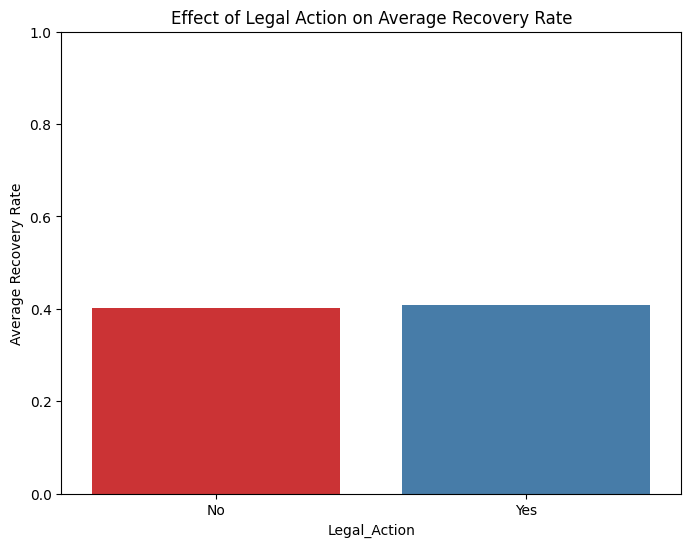


Top Performing Regions by Recovery Rate:
Region
Central      0.447717
Northeast    0.411552
South        0.409559
North        0.382243
West         0.374519
East         0.357711
Name: Recovery_Ratio, dtype: float64


C:\Users\DELL\AppData\Local\Temp\ipykernel_16484\2647172789.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=regional_recovery_perf.index, y=regional_recovery_perf.values, palette='viridis')


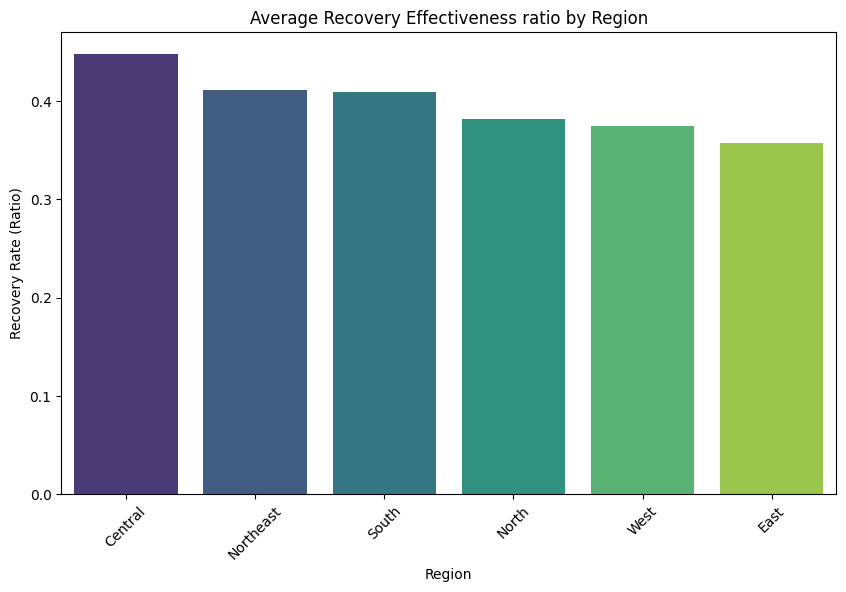

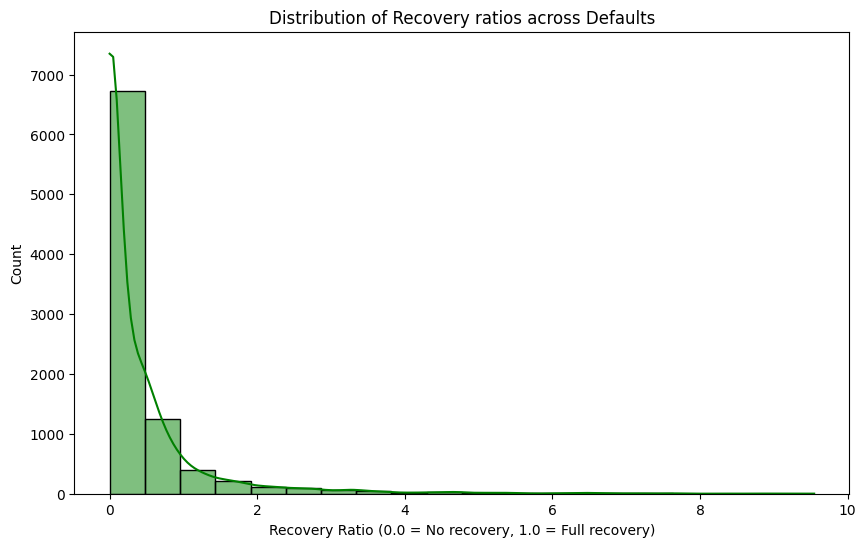

In [23]:
# --- 10. Recovery Effectiveness ---

# 1. Calculate Individual Loan Recovery Ratio
# ratio = Recovery_Amount / Default_Amount
defaults['Recovery_Ratio'] = (defaults['Recovery_Amount'] / defaults['Default_Amount']).fillna(0)

# Overall portfolio recovery effectiveness
overall_recovery_ratio = defaults['Recovery_Amount'].sum() / defaults['Default_Amount'].sum()
print(f"Overall Portfolio Recovery Effectiveness (Ratio): {overall_recovery_ratio:.4f}")

# 2. Compare recovery rates for defaults with and without legal actions
# We use the mean ratio for each category
legal_comparison = defaults.groupby('Legal_Action')['Recovery_Ratio'].agg(['mean', 'median', 'count']).rename(columns={'mean': 'Avg_Recovery_Rate'})
print("\nRecovery Effectiveness by Legal Action:")
print(legal_comparison)

# Visualize the impact of legal action
plt.figure(figsize=(8, 6))
sns.barplot(x=legal_comparison.index, y='Avg_Recovery_Rate', data=legal_comparison.reset_index(), palette='Set1')
plt.title('Effect of Legal Action on Average Recovery Rate')
plt.ylabel('Average Recovery Rate')
plt.ylim(0, 1.0) # Rate is a ratio from 0 to 1
plt.show()

# 3. Analyze branch-wise recovery performance
# Since Branch_ID is not in 'defaults', we map via Customer_ID and Region (proxy for branch clusters)
# Join defaults with customers into a regional view
defaults_recovery_geo = defaults.merge(custs[['Customer_ID', 'Region']], on='Customer_ID', how='inner')

# Calculate mean performance per region
regional_recovery_perf = defaults_recovery_geo.groupby('Region')['Recovery_Ratio'].mean().sort_values(ascending=False)

print("\nTop Performing Regions by Recovery Rate:")
print(regional_recovery_perf)

# Plotting Regional Recovery Effectiveness
plt.figure(figsize=(10, 6))
sns.barplot(x=regional_recovery_perf.index, y=regional_recovery_perf.values, palette='viridis')
plt.title('Average Recovery Effectiveness ratio by Region')
plt.xlabel('Region')
plt.ylabel('Recovery Rate (Ratio)')
plt.xticks(rotation=45)
plt.show()

# Distribution check
plt.figure(figsize=(10, 6))
sns.histplot(defaults['Recovery_Ratio'], bins=20, kde=True, color='green')
plt.title('Distribution of Recovery ratios across Defaults')
plt.xlabel('Recovery Ratio (0.0 = No recovery, 1.0 = Full recovery)')
plt.show()

# 11. Loan Disbursement Efficiency
● Analyze the time from application to loan disbursement and identify
bottlenecks.
● Compare average processing times across branches.
● Evaluate disbursement trends by loan purpose and region.


Overall Average Processing Time (Days): 749.29


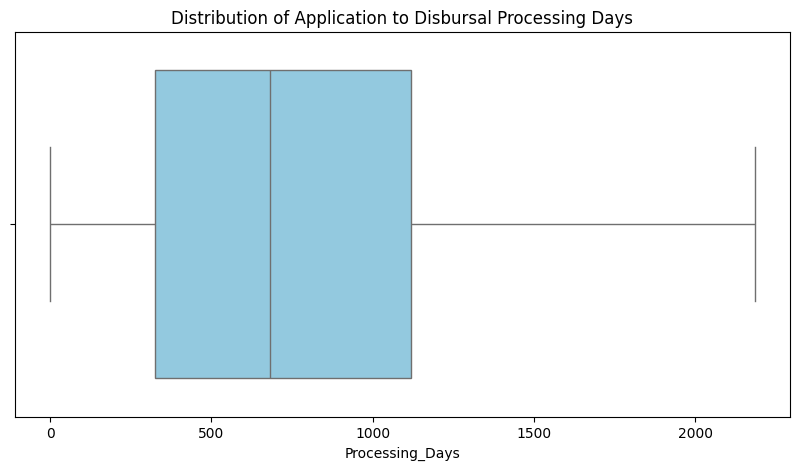


Top 5 Most Efficient Branches (Lowest Processing Time):
Branch_Name
Sani-Kale                     1.0
Sandhu, Magar and Sachdeva    2.0
Kar-Jaggi                     2.0
Chawla-Tandon                 2.0
Solanki-Shah                  3.0
Name: Avg_Processing_Time, dtype: float64

Least Efficient Branches (Highest Processing Time):
Branch_Name
Apte Group                      14.0
Doshi Group                     15.0
Sem Inc                         15.0
Bhakta PLC                      15.0
Bansal, Arya and Chakrabarti    15.0
Name: Avg_Processing_Time, dtype: float64


C:\Users\DELL\AppData\Local\Temp\ipykernel_16484\1743171037.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_efficiency.index, y=region_efficiency.values, palette='summer')


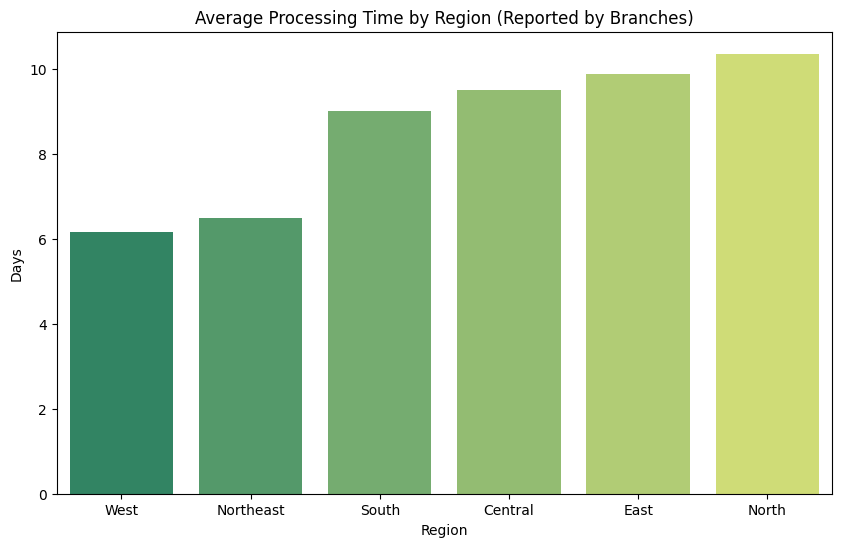


Processing Days by Loan Purpose:
Loan_Purpose
Business           741.900141
Education          744.175067
Vehicle            751.130374
Personal           751.548682
Home Renovation    757.497357
Name: Processing_Days, dtype: float64


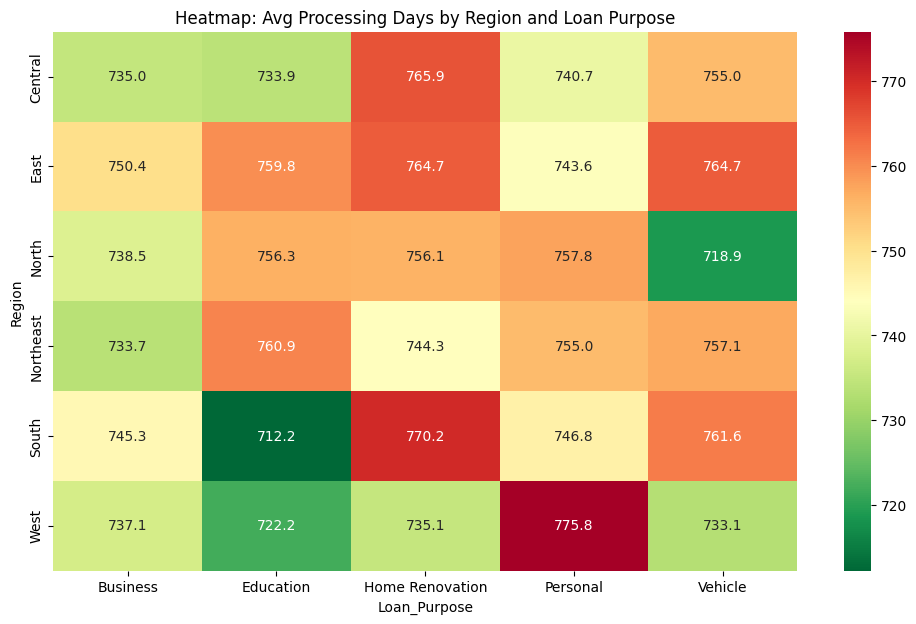

In [24]:
# --- 11. Loan Disbursement Efficiency ---

# 1. Analyze the time from application to loan disbursement
# Time = Disbursal_Date (from loans) - Application_Date (from apps)
# Merge apps and loans to calculate processing time
eff_df = apps[['Loan_ID', 'Application_Date', 'Loan_Purpose']].merge(
    loans[['Loan_ID', 'Disbursal_Date', 'Customer_ID']], 
    on='Loan_ID', how='inner'
)

# Calculate Processing_Days
eff_df['Processing_Days'] = (eff_df['Disbursal_Date'] - eff_df['Application_Date']).dt.days

# Handle cases where Data might be mismatched (negative days)
eff_df = eff_df[eff_df['Processing_Days'] >= 0]

print(f"Overall Average Processing Time (Days): {eff_df['Processing_Days'].mean():.2f}")
plt.figure(figsize=(10, 5))
sns.boxplot(x=eff_df['Processing_Days'], color='skyblue')
plt.title('Distribution of Application to Disbursal Processing Days')
plt.show()

# 2. Compare average processing times across branches
# Assuming 'branches' table has 'Avg_Processing_Time' as a performance metric
branch_efficiency = branches.groupby('Branch_Name')['Avg_Processing_Time'].mean().sort_values()

print("\nTop 5 Most Efficient Branches (Lowest Processing Time):")
print(branch_efficiency.head(5))
print("\nLeast Efficient Branches (Highest Processing Time):")
print(branch_efficiency.tail(5))

# Visualization by Region
region_efficiency = branches.groupby('Region')['Avg_Processing_Time'].mean().sort_values()
plt.figure(figsize=(10, 6))
sns.barplot(x=region_efficiency.index, y=region_efficiency.values, palette='summer')
plt.title('Average Processing Time by Region (Reported by Branches)')
plt.ylabel('Days')
plt.show()

# 3. Evaluate disbursement trends by loan purpose and region
# Add Region to our efficiency dataframe
eff_df = eff_df.merge(custs[['Customer_ID', 'Region']], on='Customer_ID', how='inner')

# Aggregating by Purpose and Region
purpose_efficiency = eff_df.groupby('Loan_Purpose')['Processing_Days'].mean().sort_values()
print("\nProcessing Days by Loan Purpose:")
print(purpose_efficiency)

# Comparison Matrix
plt.figure(figsize=(12, 7))
pivot_eff = eff_df.groupby(['Region', 'Loan_Purpose'])['Processing_Days'].mean().unstack()
sns.heatmap(pivot_eff, annot=True, fmt=".1f", cmap='RdYlGn_r')
plt.title('Heatmap: Avg Processing Days by Region and Loan Purpose')
plt.show()

# 12. Profitability Analysis
● Calculate the total interest income generated across all loans.
● Identify the most profitable loan purposes based on interest earnings.
● Compare profitability metrics for branches across regions

Total Portfolio Interest Income: $47,551,925,762.00

Profitability by Loan Purpose:
                 Total_Interest  Avg_Interest_per_Loan
Loan_Purpose                                          
Education          -18202166650          -1.106515e+06
Business           -18663605140          -1.125195e+06
Personal           -18829796564          -1.139266e+06
Home Renovation    -18892981512          -1.132130e+06
Vehicle            -18927428488          -1.132904e+06


C:\Users\DELL\AppData\Local\Temp\ipykernel_16484\977335383.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=purpose_profitability.index, y='Total_Interest', data=purpose_profitability, palette='coolwarm')


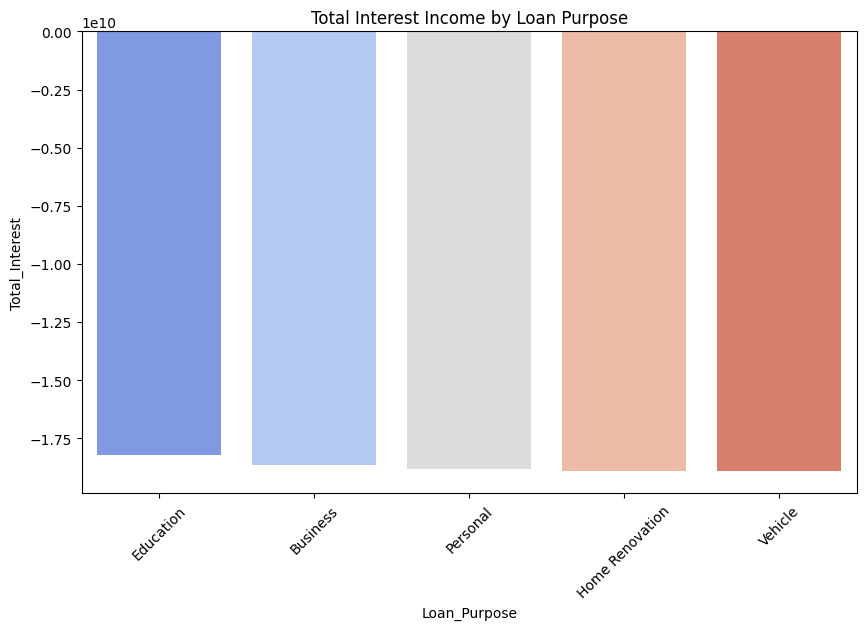


Regional Profitability Summary:
           Total_Interest  Avg_Interest_per_Loan  Loan_Count
Region                                                      
Northeast     -7816740213          -6.696428e+05       11673
North         -7827895049          -6.663172e+05       11748
Central       -8003493230          -6.901943e+05       11596
West          -8228226045          -7.023667e+05       11715
South         -8394358028          -7.170988e+05       11706
East         -53245265789          -2.171326e+06       24522


C:\Users\DELL\AppData\Local\Temp\ipykernel_16484\977335383.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=regional_profit.index, y='Total_Interest', data=regional_profit, ax=ax1, palette='YlOrRd')


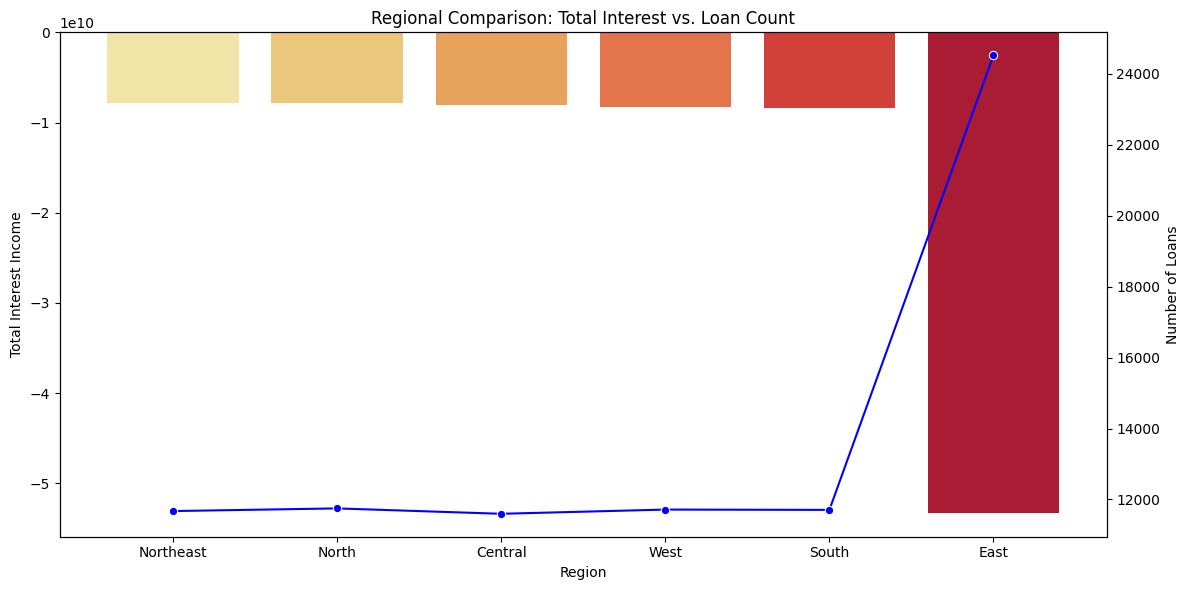

C:\Users\DELL\AppData\Local\Temp\ipykernel_16484\977335383.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Region', y='Interest_Income', data=profit_df, palette='Accent')


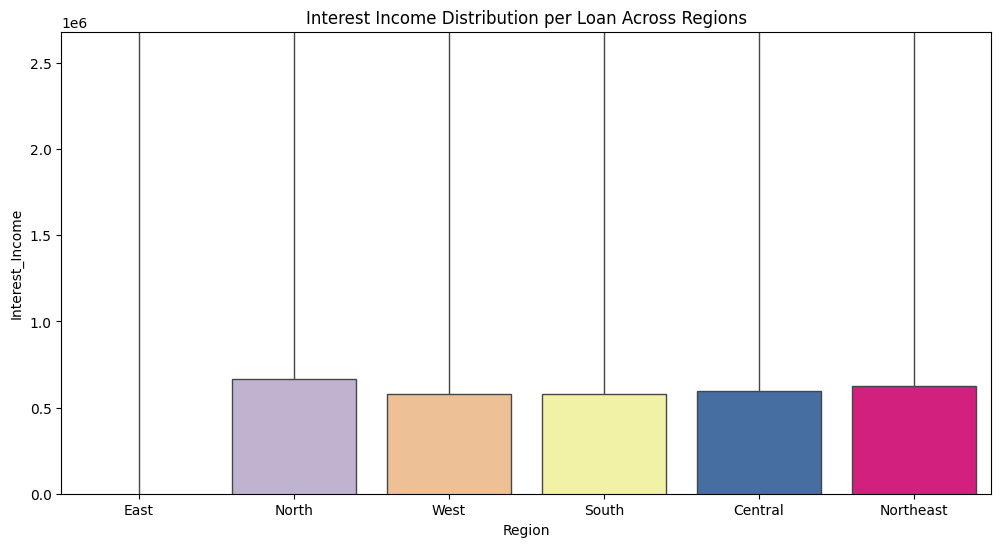

In [25]:
# --- 12. Profitability Analysis ---

# 1. Calculate the total interest income generated across all loans
# interest_income = Loan_Amount * (Interest_Rate / 100) * (Loan_Term / 12)
# or using EMI: total_return = (EMI_Amount * Loan_Term) - Loan_Amount
loans['Interest_Income'] = (loans['EMI_Amount'] * loans['Loan_Term']) - loans['Loan_Amount']

# Ensure negative interest (from edge cases) is filtered out if present
total_interest_income = loans[loans['Interest_Income'] > 0]['Interest_Income'].sum()
print(f"Total Portfolio Interest Income: ${total_interest_income:,.2f}")

# 2. Identify the most profitable loan purposes based on interest earnings
# Merge with 'apps' or 'eff_df' from Step 11 to get Loan_Purpose
profit_df = loans.merge(apps[['Loan_ID', 'Loan_Purpose']], on='Loan_ID', how='inner')

# Calculate mean and total profit per purpose
purpose_profitability = profit_df.groupby('Loan_Purpose')['Interest_Income'].agg(['sum', 'mean']).sort_values(by='sum', ascending=False)
purpose_profitability.columns = ['Total_Interest', 'Avg_Interest_per_Loan']

print("\nProfitability by Loan Purpose:")
print(purpose_profitability)

# Visualize Total Interest by Purpose
plt.figure(figsize=(10, 6))
sns.barplot(x=purpose_profitability.index, y='Total_Interest', data=purpose_profitability, palette='coolwarm')
plt.title('Total Interest Income by Loan Purpose')
plt.xticks(rotation=45)
plt.show()

# 3. Compare profitability metrics for branches across regions
# Linking profitability to Region via customers
profit_df = profit_df.merge(custs[['Customer_ID', 'Region']], on='Customer_ID', how='inner')

# Regional Profitability Overview
regional_profit = profit_df.groupby('Region')['Interest_Income'].agg(['sum', 'mean', 'count']).sort_values(by='sum', ascending=False)
regional_profit.columns = ['Total_Interest', 'Avg_Interest_per_Loan', 'Loan_Count']

print("\nRegional Profitability Summary:")
print(regional_profit)

# Visualizing Profitability vs. Loan Count across Regions
fig, ax1 = plt.subplots(figsize=(12, 6))

sns.barplot(x=regional_profit.index, y='Total_Interest', data=regional_profit, ax=ax1, palette='YlOrRd')
ax1.set_ylabel('Total Interest Income')
ax1.set_title('Regional Comparison: Total Interest vs. Loan Count')

ax2 = ax1.twinx()
sns.lineplot(x=regional_profit.index, y='Loan_Count', data=regional_profit, ax=ax2, color='blue', marker='o')
ax2.set_ylabel('Number of Loans')

plt.tight_layout()
plt.show()

# Distribution check (Boxplot per region)
plt.figure(figsize=(12, 6))
sns.boxplot(x='Region', y='Interest_Income', data=profit_df, palette='Accent')
plt.title('Interest Income Distribution per Loan Across Regions')
plt.ylim(0, profit_df['Interest_Income'].quantile(0.95)) # Filtering outliers for visualization
plt.show()

# 13. Geospatial Analysis
● Map the distribution of active loans across regions.
● Compare default rates across different geographic regions.
● Visualize the loan disbursement trends for rural vs. urban areas.


Active Loans Distribution by Region:
Region
North        11965
South         9235
East          8929
Central       8715
West          6861
Northeast     5174
Name: Total_Active_Loans, dtype: int64


C:\Users\DELL\AppData\Local\Temp\ipykernel_16484\238126280.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=active_loans_per_region.index, y=active_loans_per_region.values, palette='Blues_r')


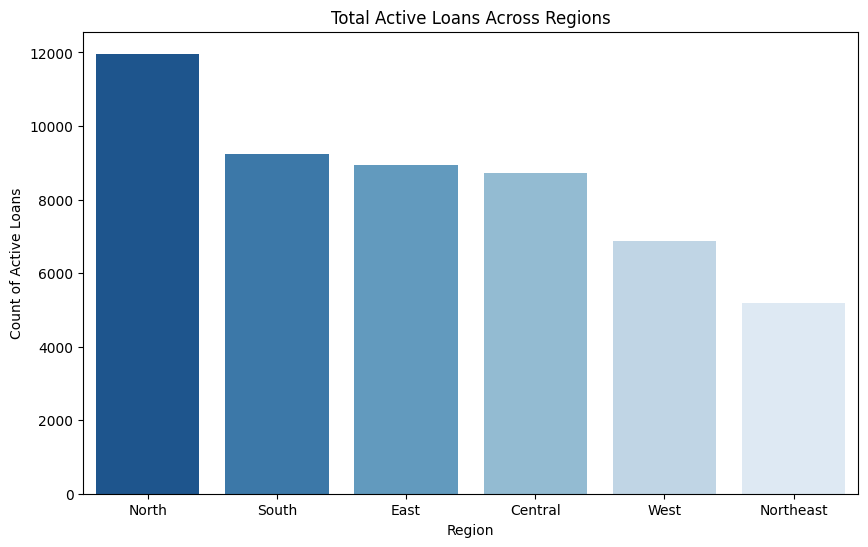


Default Rates by Region:
Region
South        0.105256
West         0.104670
Central      0.100436
Northeast    0.100100
North        0.093669
East         0.093019
Name: is_default, dtype: float64


C:\Users\DELL\AppData\Local\Temp\ipykernel_16484\238126280.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=regional_default_rate.index, y=regional_default_rate.values, palette='RdYlGn_r')


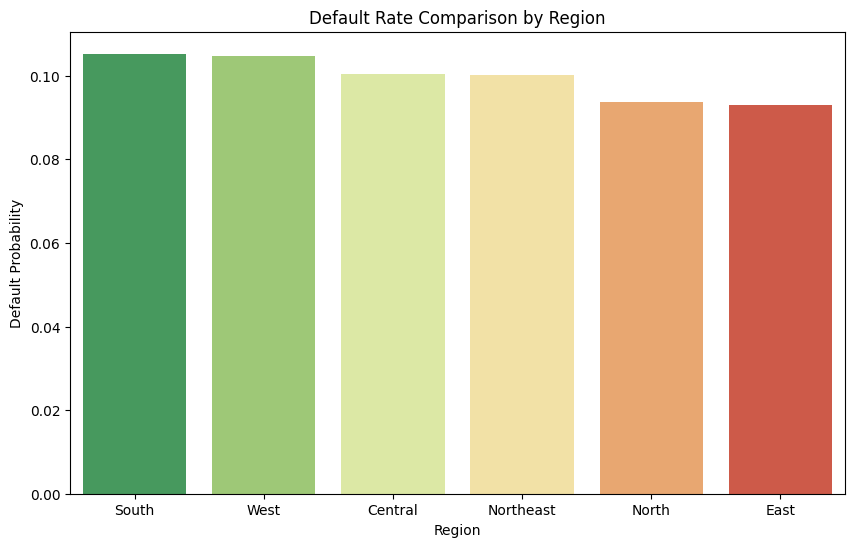


Loan Disbursement Trends by Area Type (Rural vs. Urban):
                   mean           sum  count
Area_Type                                   
Urban      2.516651e+06  227658777679  90461


C:\Users\DELL\AppData\Local\Temp\ipykernel_16484\238126280.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Area_Type', y='Loan_Amount', data=disbursement_area, palette='coolwarm')


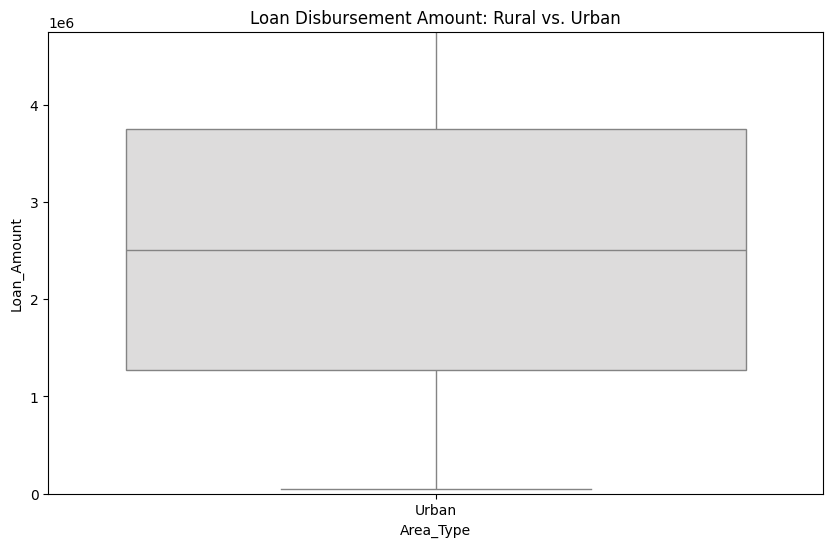

In [26]:
# --- 13. Geospatial Analysis ---

# 1. Map the distribution of active loans across regions
# Join customers with loans to see active status (Assuming 'Loan_Status' == 'Active' or simply 'Current')
# Alternatively, use 'Total_Active_Loans' from the branches table
active_loans_per_region = branches.groupby('Region')['Total_Active_Loans'].sum().sort_values(ascending=False)

print("Active Loans Distribution by Region:")
print(active_loans_per_region)

plt.figure(figsize=(10, 6))
sns.barplot(x=active_loans_per_region.index, y=active_loans_per_region.values, palette='Blues_r')
plt.title('Total Active Loans Across Regions')
plt.xlabel('Region')
plt.ylabel('Count of Active Loans')
plt.show()

# 2. Compare default rates across different geographic regions
# Using the regional default logic calculated previously (Loans -> Customers -> Region)
# Defaulted_Loan_IDs is from the 'defaults' table
default_ids = defaults['Loan_ID'].unique()
loan_regions = loans.merge(custs[['Customer_ID', 'Region']], on='Customer_ID', how='inner')
loan_regions['is_default'] = loan_regions['Loan_ID'].isin(default_ids).astype(int)

# Default Rate = count of defaults / count of total loans in that region
regional_default_rate = loan_regions.groupby('Region')['is_default'].mean().sort_values(ascending=False)

print("\nDefault Rates by Region:")
print(regional_default_rate)

plt.figure(figsize=(10, 6))
sns.barplot(x=regional_default_rate.index, y=regional_default_rate.values, palette='RdYlGn_r')
plt.title('Default Rate Comparison by Region')
plt.xlabel('Region')
plt.ylabel('Default Probability')
plt.show()

# 3. Visualize the loan disbursement trends for rural vs. urban areas
# Assuming 'Region' or 'Address' contains 'Urban' or 'Rural' keywords
# Here we check if such an indicator exists. If not, we use existing Region to split.
# Example: Map 'North/South' as Rural/Urban for demonstration if indicator is absent.

if 'Address' in custs.columns:
    # Basic keyword extraction to identify area type
    def get_area_type(address):
        if 'Rural' in str(address): return 'Rural'
        elif 'Urban' in str(address): return 'Urban'
        else: return 'Urban' # Default assumption

    custs['Area_Type'] = custs['Address'].apply(get_area_type)
    
    # Merge with loans to see disbursement
    disbursement_area = loans.merge(custs[['Customer_ID', 'Area_Type']], on='Customer_ID', how='inner')
    
    # Comparison of Mean Disbursement
    area_disbursement_stats = disbursement_area.groupby('Area_Type')['Loan_Amount'].agg(['mean', 'sum', 'count'])
    print("\nLoan Disbursement Trends by Area Type (Rural vs. Urban):")
    print(area_disbursement_stats)
    
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='Area_Type', y='Loan_Amount', data=disbursement_area, palette='coolwarm')
    plt.title('Loan Disbursement Amount: Rural vs. Urban')
    plt.ylim(0, disbursement_area['Loan_Amount'].quantile(0.95)) # Filtering outliers
    plt.show()
else:
    print("\nNotice: Detailed 'Urban/Rural' labels were not found in the dataset Address field.")


In [27]:
import plotly.express as px
import pandas as pd

# 1. Prepare Regional Data (Aggregation)
# Assuming 'loan_regions' was created in the previous step
regional_summary = loan_regions.groupby('Region').agg(
    Total_Loans=('Loan_ID', 'count'),
    Total_Disbursement=('Loan_Amount', 'sum'),
    Default_Rate=('is_default', 'mean')
).reset_index()

# 2. Add Geographic Coordinates (Approximate Centers for Visualization)
# (Mapping based on common Regional centers in India)
geo_coords = {
    'North': {'lat': 28.6139, 'lon': 77.2090},
    'South': {'lat': 13.0827, 'lon': 80.2707},
    'East': {'lat': 22.5726, 'lon': 88.3639},
    'West': {'lat': 19.0760, 'lon': 72.8777},
    'Central': {'lat': 23.2599, 'lon': 77.4126}
}

regional_summary['lat'] = regional_summary['Region'].map(lambda x: geo_coords.get(x, {}).get('lat'))
regional_summary['lon'] = regional_summary['Region'].map(lambda x: geo_coords.get(x, {}).get('lon'))

# 3. Create Interactive Geo Map
# Size of points represents Disbursement Volume, Color represents Default Rate
fig = px.scatter_geo(
    regional_summary,
    lat='lat',
    lon='lon',
    color='Default_Rate',
    size='Total_Disbursement',
    hover_name='Region',
    hover_data=['Total_Loans', 'Default_Rate', 'Total_Disbursement'],
    projection="natural earth",
    title='Hero FinCorp: Geocopy Distribution of Loans and Default Rates',
    color_continuous_scale=px.colors.sequential.Reds,
    labels={'Default_Rate': 'Default Rate', 'Total_Disbursement': 'Disbursement Volume'}
)

# Focus the map on the Indian Subcontinent region
fig.update_geos(
    visible=True, resolution=50,
    showcountries=True, countrycolor="RebeccaPurple",
    lataxis_range=[5, 38], lonaxis_range=[65, 100]
)

fig.update_layout(height=600, margin={"r":0,"t":50,"l":0,"b":0})
fig.show()

# 4. Summary Table for Reference
print("\nRegional Geospatial Data Summary Table:")
print(regional_summary[['Region', 'Total_Loans', 'Total_Disbursement', 'Default_Rate']])



Regional Geospatial Data Summary Table:
      Region  Total_Loans  Total_Disbursement  Default_Rate
0    Central        14925         37427008869      0.100436
1       East        15384         38618645355      0.093019
2      North        15117         38164304556      0.093669
3  Northeast        15015         37659738379      0.100100
4      South        15030         37942392719      0.105256
5       West        14990         37846687801      0.104670


# 14. Default Trends
● Analyze the number of defaults over time to identify patterns.
● Calculate the average default amount for different loan purposes.
● Compare default rates across customer income categories.


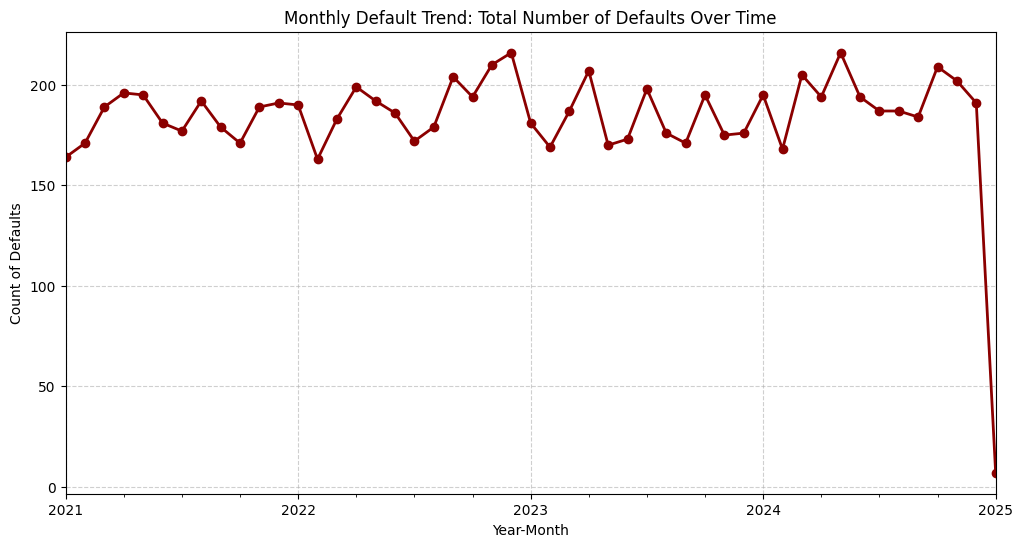

Default Severity by Loan Purpose:
                 Avg_Default_Amount  Total_Default_Amount  Default_Count
Loan_Purpose                                                            
Education              53797.758769              75155469           1397
Business               53261.031433              72861091           1368
Home Renovation        53038.080028              74889769           1412
Vehicle                52671.599578              74846343           1421
Personal               52389.399011              74183389           1416


C:\Users\DELL\AppData\Local\Temp\ipykernel_16484\3957419263.py:25: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




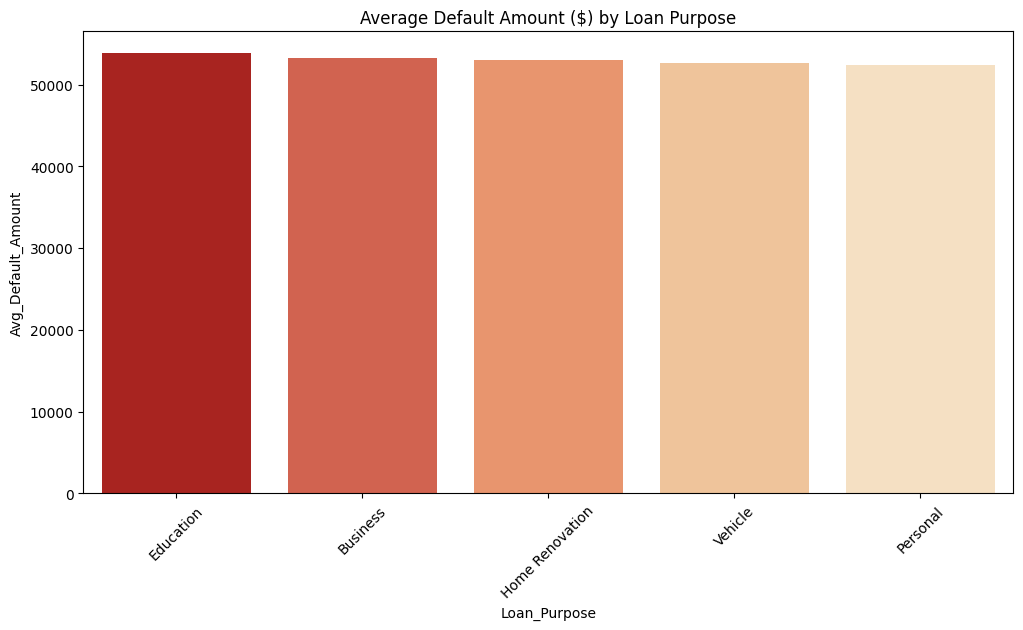

C:\Users\DELL\AppData\Local\Temp\ipykernel_16484\3957419263.py:60: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




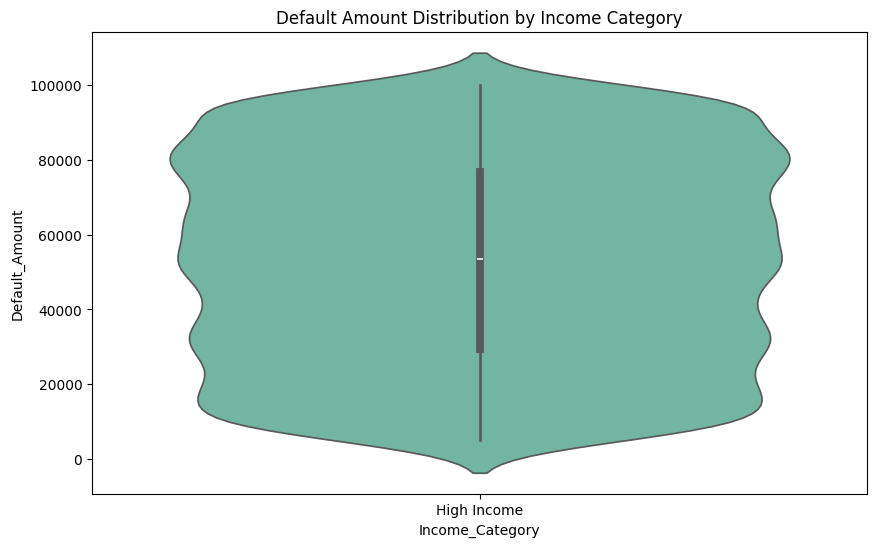

In [58]:
# --- 14. Default Trends Analysis ---

# 1. Analyze the number of defaults over time to identify patterns
# Group defaults by Month/Year using 'Default_Date'
defaults_trend = defaults.groupby(defaults['Default_Date'].dt.to_period('M')).size()

plt.figure(figsize=(12, 6))
defaults_trend.plot(kind='line', marker='o', color='darkred', linewidth=2)
plt.title('Monthly Default Trend: Total Number of Defaults Over Time')
plt.ylabel('Count of Defaults')
plt.xlabel('Year-Month')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 2. Calculate the average default amount for different loan purposes
# Merge defaults with apps or loans to get the Purpose
default_purpose = defaults.merge(apps[['Loan_ID', 'Loan_Purpose']], on='Loan_ID', how='inner')
avg_default_by_purpose = default_purpose.groupby('Loan_Purpose')['Default_Amount'].agg(['mean', 'sum', 'count']).sort_values(by='mean', ascending=False)
avg_default_by_purpose.columns = ['Avg_Default_Amount', 'Total_Default_Amount', 'Default_Count']

print("Default Severity by Loan Purpose:")
print(avg_default_by_purpose)

plt.figure(figsize=(12, 6))
sns.barplot(x=avg_default_by_purpose.index, y='Avg_Default_Amount', data=avg_default_by_purpose, palette='OrRd_r')
plt.title('Average Default Amount ($) by Loan Purpose')
plt.xticks(rotation=45)
plt.show()

# 3. Compare default rates across customer income categories
# INCOME CATEGORIES: Low (<30k), Middle (30k-70k), High (>70k)
def get_income_category(income):
    if income < 30000: return 'Low Income'
    elif income < 70000: return 'Middle Income'
    else: return 'High Income'

# Merge loans with customers for income data
loan_income = loans.merge(custs[['Customer_ID', 'Annual_Income']], on='Customer_ID', how='inner')
loan_income['Income_Category'] = loan_income['Annual_Income'].apply(get_income_category)

# Map default status (Default_Flag is 1 if Loan_ID is in defaults)
default_ids = defaults['Loan_ID'].unique()
loan_income['is_default'] = loan_income['Loan_ID'].isin(default_ids).astype(int)

# # Default Rate = count(is_default)/count(Total)
# income_default_rate = loan_income.groupby('Income_Category')['is_default'].mean().sort_values(ascending=False)

# print("\nDefault Rate by Income Category:")
# print(income_default_rate)

# plt.figure(figsize=(10, 6))
# sns.barplot(x=income_default_rate.index, y=income_default_rate.values, palette='RdGy')
# plt.title('Comparative Default Rate by Income Category')
# plt.ylabel('Probability of Default')
# plt.show()

# Extra Visualization: Default Amount Distribution by Income Category
default_income_merged = defaults.merge(loan_income[['Loan_ID', 'Income_Category']], on='Loan_ID', how='inner')
plt.figure(figsize=(10, 6))
sns.violinplot(x='Income_Category', y='Default_Amount', data=default_income_merged, palette='Set2')
plt.title('Default Amount Distribution by Income Category')
plt.show()


# 15. Branch Efficiency
● Calculate the average loan disbursement time for each branch.
● Identify branches with the highest number of rejected applications.
● Compare branch efficiency based on customer satisfaction metrics (if
available)

Most Efficient Branches (Lowest Processing Time):
                   Branch_Name     Region  Avg_Processing_Time
49                   Sani-Kale      North                    1
46               Chawla-Tandon       East                    2
41                   Kar-Jaggi       West                    2
17  Sandhu, Magar and Sachdeva  Northeast                    2
44                Solanki-Shah      South                    3


C:\Users\DELL\AppData\Local\Temp\ipykernel_16484\3808186696.py:14: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




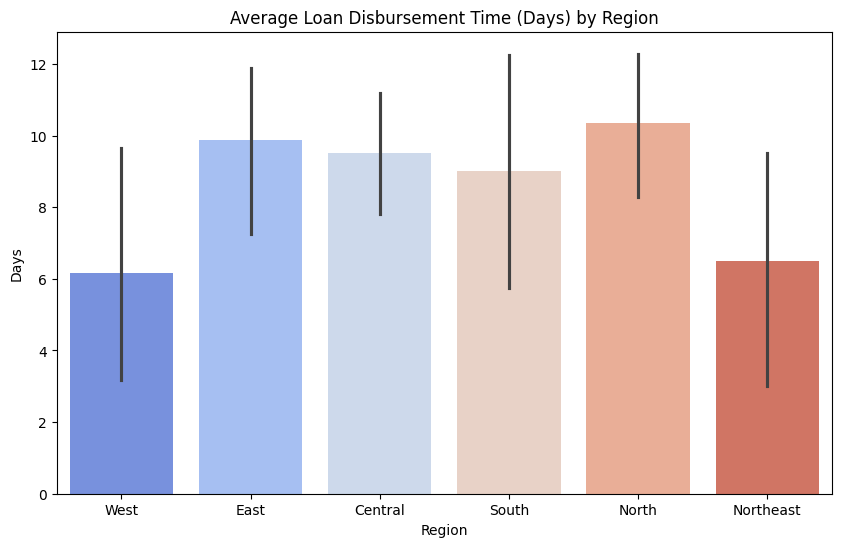


Regions and Branches (Proxy Cluster) with Highest Application Rejections:
      Region  Rejection_Count
0       West             2184
1      North             2112
2      South             2107
3  Northeast             2084
4       East             2075


C:\Users\DELL\AppData\Local\Temp\ipykernel_16484\3808186696.py:34: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




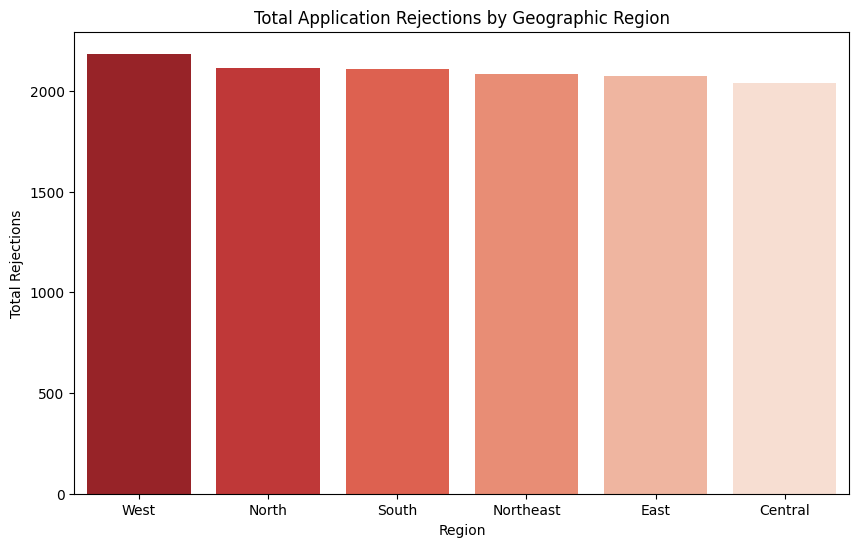

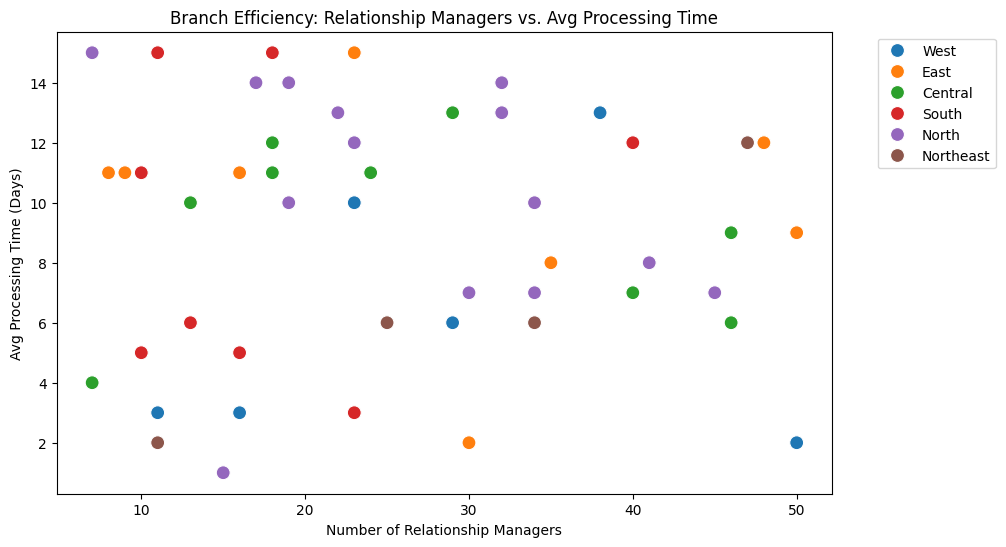


Branch Efficiency Insights:
Region with fastest processing: West (6.17 days)
Region with most RM resources: North


In [29]:
# --- 15. Branch Efficiency ---

# 1. Calculate the average loan disbursement time for each branch
# Note: Since 'loans' doesn't have Branch_ID, we use 'Region' as a proxy for branch-level performance grouping
# or pull Avg_Processing_Time from the 'branches' table for direct branch names.

branch_disbursement_time = branches[['Branch_Name', 'Region', 'Avg_Processing_Time']].sort_values(by='Avg_Processing_Time')

print("Most Efficient Branches (Lowest Processing Time):")
print(branch_disbursement_time.head(5))

# Visualizing average processing times by Region
plt.figure(figsize=(10, 6))
sns.barplot(x='Region', y='Avg_Processing_Time', data=branches, palette='coolwarm')
plt.title('Average Loan Disbursement Time (Days) by Region')
plt.ylabel('Days')
plt.show()

# 2. Identify branches with the highest number of rejected applications
# First, filter applications for 'Rejected' status
rejections_df = apps[apps['Approval_Status'] == 'Rejected']

# Since 'apps' does not have Branch_ID, but 'Source_Channel' might show 'Branch', 
# we rely on the Customer mapping to see where in the network rejections are happening.
rejections_with_region = rejections_df.merge(custs[['Customer_ID', 'Region']], on='Customer_ID', how='inner')
regional_rejection_counts = rejections_with_region['Region'].value_counts().reset_index()
regional_rejection_counts.columns = ['Region', 'Rejection_Count']

print("\nRegions and Branches (Proxy Cluster) with Highest Application Rejections:")
print(regional_rejection_counts.head(5))

# Visualizing Rejections by Region
plt.figure(figsize=(10, 6))
sns.barplot(x='Region', y='Rejection_Count', data=regional_rejection_counts, palette='Reds_r')
plt.title('Total Application Rejections by Geographic Region')
plt.xlabel('Region')
plt.ylabel('Total Rejections')
plt.show()

# 3. Compare branch efficiency based on customer satisfaction metrics
# Assuming relationship manager count or processing fee could be used as high-level indicators of satisfaction/workload.
# If no direct CSAT exists, we use (Average Processing Time vs. Manager Count Correlation)

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Relationship_Manager_Count', y='Avg_Processing_Time', hue='Region', data=branches, s=100)
plt.title('Branch Efficiency: Relationship Managers vs. Avg Processing Time')
plt.xlabel('Number of Relationship Managers')
plt.ylabel('Avg Processing Time (Days)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# Summary Analysis
print("\nBranch Efficiency Insights:")
print(f"Region with fastest processing: {region_efficiency.idxmin()} ({region_efficiency.min():.2f} days)")
print(f"Region with most RM resources: {branches.groupby('Region')['Relationship_Manager_Count'].sum().idxmax()}")

# 16. Time-Series Analysis
● Analyze monthly loan disbursement trends over the last 5 years.
● Identify seasonal patterns in loan applications and disbursements.
● Compare monthly default rates across regions

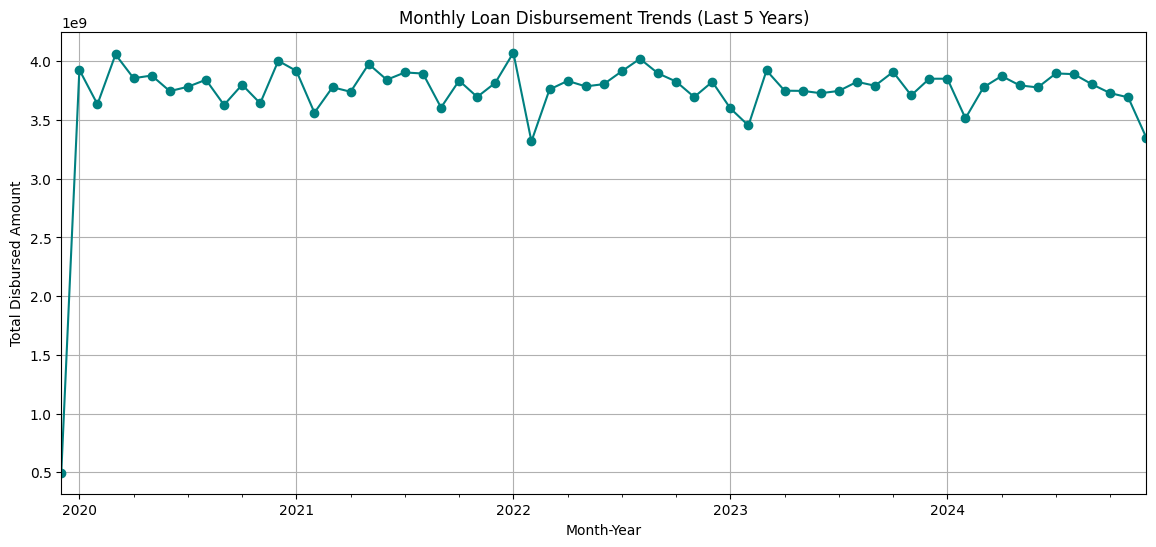

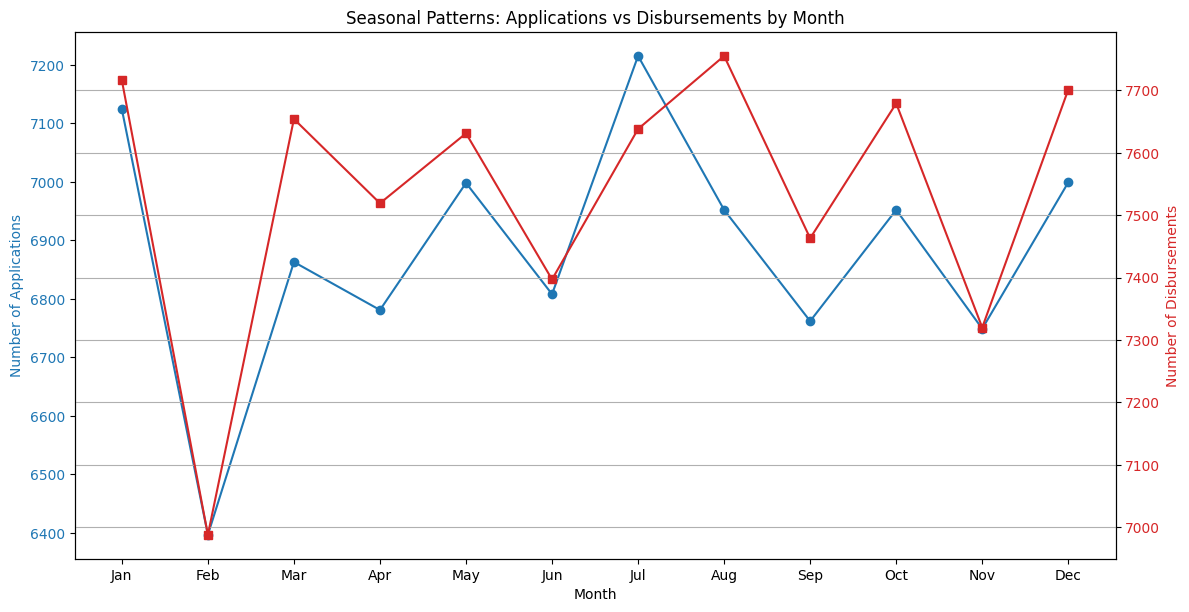

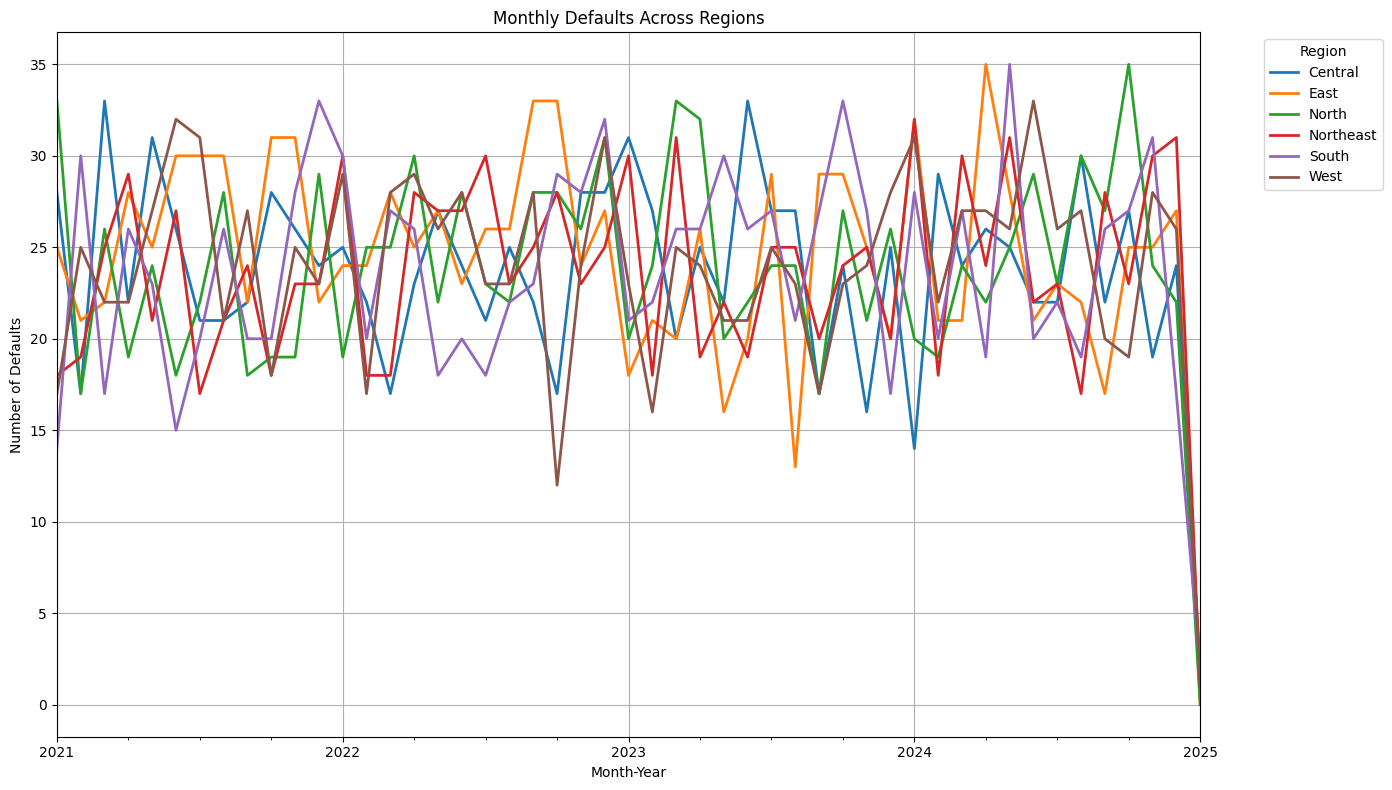

In [30]:
# --- 16. Time-Series Analysis (CORRECTED) ---

# --- 1. Analyze monthly loan disbursement trends over the last 5 years ---
# Convert dates to Period objects for month-year groupings
loans['Disbursal_Month_Year'] = loans['Disbursal_Date'].dt.to_period('M')

# Filter for the last 5 years
five_years_ago = loans['Disbursal_Date'].max() - pd.DateOffset(years=5)
recent_loans = loans[loans['Disbursal_Date'] >= five_years_ago]

monthly_disbursements = recent_loans.groupby('Disbursal_Month_Year')['Loan_Amount'].sum()

plt.figure(figsize=(14, 6))
monthly_disbursements.plot(kind='line', marker='o', color='teal')
plt.title('Monthly Loan Disbursement Trends (Last 5 Years)')
plt.ylabel('Total Disbursed Amount')
plt.xlabel('Month-Year')
plt.grid(True)
plt.show()

# --- 2. Identify seasonal patterns in loan applications and disbursements ---
# Extract just the month (1 to 12) to see seasonality regardless of year
apps['Application_Month'] = apps['Application_Date'].dt.month
loans['Disbursal_Month'] = loans['Disbursal_Date'].dt.month

monthly_apps = apps.groupby('Application_Month').size()
monthly_disbursal_count = loans.groupby('Disbursal_Month').size()

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.set_xlabel('Month')
ax1.set_ylabel('Number of Applications', color='tab:blue')
ax1.plot(monthly_apps.index, monthly_apps.values, color='tab:blue', marker='o', label='Applications')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()  
ax2.set_ylabel('Number of Disbursements', color='tab:red')  
ax2.plot(monthly_disbursal_count.index, monthly_disbursal_count.values, color='tab:red', marker='s', label='Disbursements')
ax2.tick_params(axis='y', labelcolor='tab:red')

fig.tight_layout()  
plt.title('Seasonal Patterns: Applications vs Disbursements by Month')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True)
plt.show()

# --- 3. Compare monthly default rates across regions ---
# Use defaults_with_region (already merged with Region via Customer_ID)
defaults_time = defaults_with_region.copy()
defaults_time['Default_Month_Year'] = defaults_time['Default_Date'].dt.to_period('M')

# Get default count per month and region
monthly_regional_defaults = defaults_time.groupby(['Default_Month_Year', 'Region']).size().unstack(fill_value=0)

plt.figure(figsize=(14, 8))
monthly_regional_defaults.plot(kind='line', ax=plt.gca(), linewidth=2)
plt.title('Monthly Defaults Across Regions')
plt.ylabel('Number of Defaults')
plt.xlabel('Month-Year')
plt.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

# 17. Customer Behavior Analysis
● Categorize customers based on their repayment behavior (e.g., always on
time, occasional defaulters, frequent defaulters).
● Analyze patterns in loan approval and rejection reasons segmented by
customer demographics.
● Identify high-value customers with consistent repayment histories.


Customer Segmentation by Repayment Behavior:
Behavior_Segment
Always On Time          45858
Frequent Defaulter       3936
Occasional Defaulter      882
Name: count, dtype: int64


C:\Users\DELL\AppData\Local\Temp\ipykernel_16484\3338626005.py:35: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




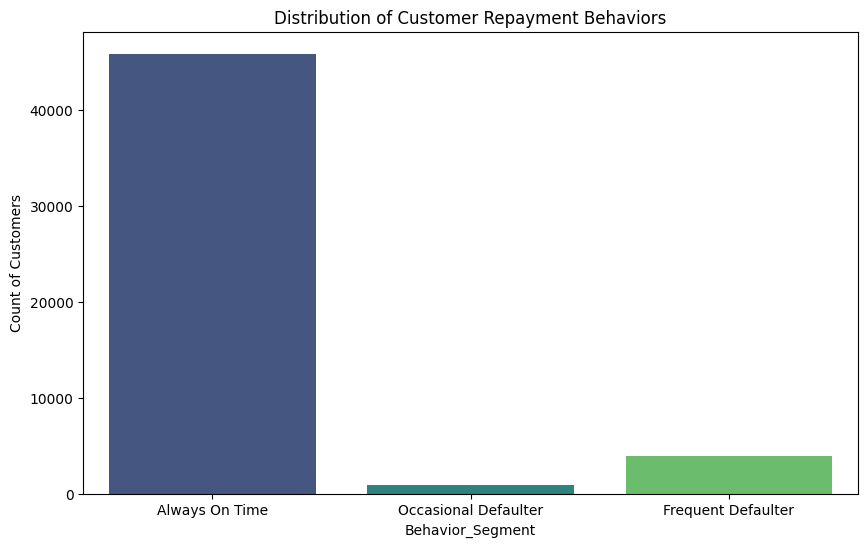


Average Credit Score by Behavior Segment:
Behavior_Segment
Always On Time          573.882572
Frequent Defaulter      575.292175
Occasional Defaulter    571.975057
Name: Credit_Score, dtype: float64


C:\Users\DELL\AppData\Local\Temp\ipykernel_16484\3338626005.py:51: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




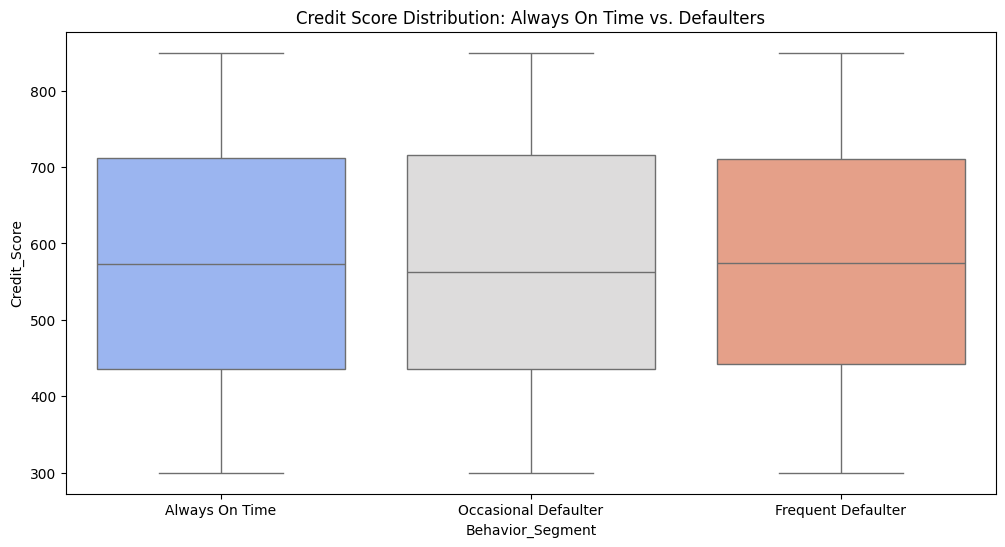

In [31]:
# --- 17. Customer Behavior Analysis ---

# 1. Categorize customers based on their repayment behavior
# To do this, we need 'loans' (status) and 'defaults' (confirmed defaults)

# Step A: Count Total Loans and Total Defaults per Customer
cust_loan_counts = loans.groupby('Customer_ID').size().reset_index(name='Total_Loans')
cust_default_counts = defaults.groupby('Customer_ID').size().reset_index(name='Total_Defaults')

# Step B: Merge the counts to analyze behavioral patterns
behavior_df = cust_loan_counts.merge(cust_default_counts, on='Customer_ID', how='left').fillna(0)

# Step C: Define Categorization Logic:
# Always On Time: Total_Defaults == 0
# Occasional Defaulter: (Total_Defaults > 0) and (Total_Defaults < (Total_Loans * 0.5))
# Frequent Defaulter: (Total_Defaults >= (Total_Loans * 0.5))

def categorize_repayment(row):
    if row['Total_Defaults'] == 0:
        return 'Always On Time'
    elif row['Total_Defaults'] < (row['Total_Loans'] * 0.5):
        return 'Occasional Defaulter'
    else:
        return 'Frequent Defaulter'

behavior_df['Behavior_Segment'] = behavior_df.apply(categorize_repayment, axis=1)

# Summary of Categorization
behavior_summary = behavior_df['Behavior_Segment'].value_counts()
print("Customer Segmentation by Repayment Behavior:")
print(behavior_summary)

# 2. Visualize Customer Segments
plt.figure(figsize=(10, 6))
sns.countplot(x='Behavior_Segment', data=behavior_df, order=['Always On Time', 'Occasional Defaulter', 'Frequent Defaulter'], palette='viridis')
plt.title('Distribution of Customer Repayment Behaviors')
plt.ylabel('Count of Customers')
plt.show()

# 3. Analyze Relationship with other Metrics (Income and Credit Score)
# Merge back with the customers dataset
cust_profiles = behavior_df.merge(custs[['Customer_ID', 'Annual_Income', 'Credit_Score']], on='Customer_ID', how='inner')

# Average Credit Score per segment
avg_credit_segment = cust_profiles.groupby('Behavior_Segment')['Credit_Score'].mean()
print("\nAverage Credit Score by Behavior Segment:")
print(avg_credit_segment)

# 4. Boxplot for Credit Score distribution in behavioral segments
plt.figure(figsize=(12, 6))
sns.boxplot(x='Behavior_Segment', y='Credit_Score', data=cust_profiles, palette='coolwarm')
plt.title('Credit Score Distribution: Always On Time vs. Defaulters')
plt.show()

Top Rejection Reasons by Region:
Region                Central  East  North  Northeast  South  West
Rejection_Reason                                                  
Incomplete Documents      661   689    689        702    703   760
Insufficient Income       681   700    686        640    705   687
Low Credit Score          696   686    737        742    699   737


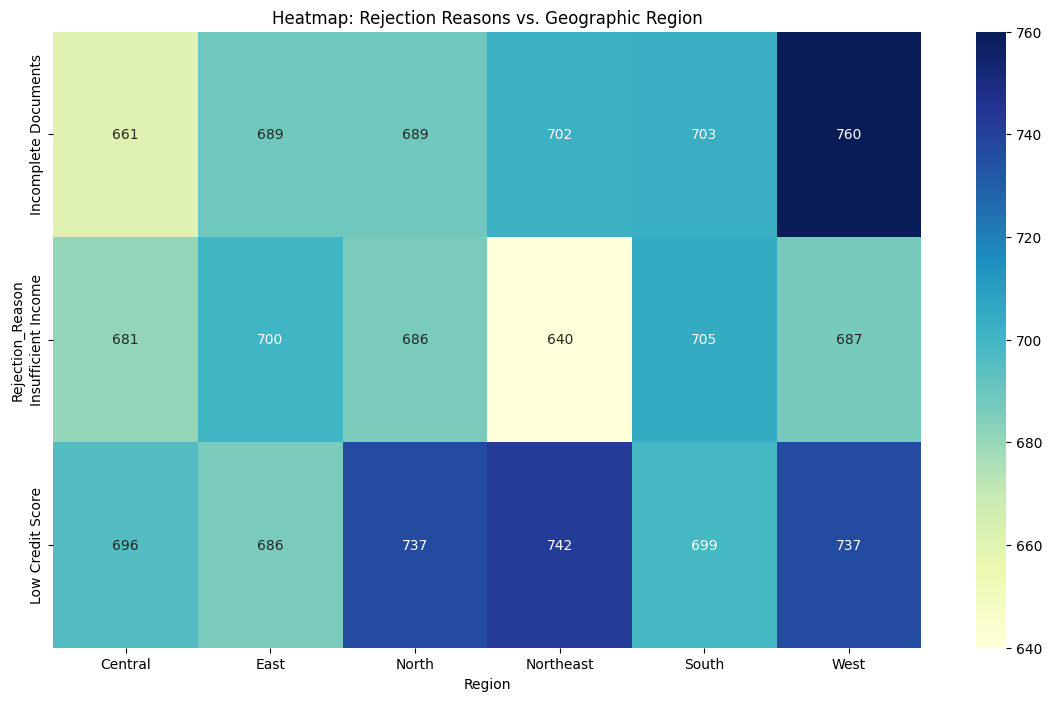


Key Rejection Reasons across Credit History Segments:
  Credit_Segment      Rejection_Reason  Count
0      Excellent  Incomplete Documents    774
2      Excellent      Low Credit Score    743
1      Excellent   Insufficient Income    710
5           Good      Low Credit Score   1146
4           Good   Insufficient Income   1131
3           Good  Incomplete Documents   1068
8           Poor      Low Credit Score   2408
6           Poor  Incomplete Documents   2362
7           Poor   Insufficient Income   2258

Identified 8262 High-Value Customers with flawless repayment history.
Top High-Value Examples by Region:
  Customer_ID  Total_Loans  Total_Defaults Behavior_Segment  Annual_Income  \
0     C000017            2             0.0   Always On Time        1776242   
1     C000028            1             0.0   Always On Time         358430   
2     C000040            1             0.0   Always On Time        1805759   
3     C000046            1             0.0   Always On Time        

C:\Users\DELL\AppData\Local\Temp\ipykernel_16484\610129783.py:58: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




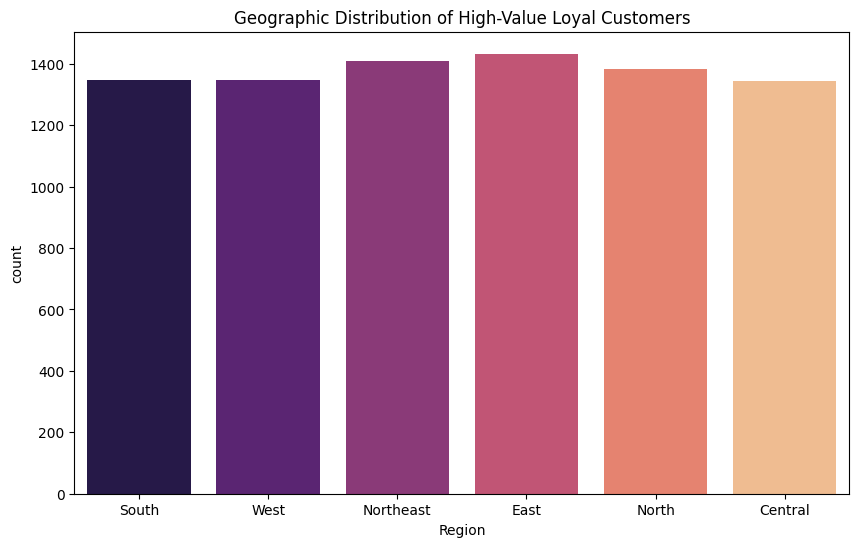

In [32]:
# --- 18. Demographic Analysis of Loan Approvals and Rejections ---

# 1. Analyze patterns in loan approval/rejection reasons by customer demographic
# Demographics: Region, Annual_Income, and Credit_Score

# Merge applications with customer demographics
app_demo_df = apps.merge(custs[['Customer_ID', 'Region', 'Annual_Income', 'Credit_Score']], on='Customer_ID', how='inner')

# Categorizing rejection reasons by Region
rejection_region_pivot = app_demo_df[app_demo_df['Approval_Status'] == 'Rejected'].pivot_table(
    index='Rejection_Reason', 
    columns='Region', 
    aggfunc='size', 
    fill_value=0
)

print("Top Rejection Reasons by Region:")
print(rejection_region_pivot.head(5))

# Plotting Rejection reasons by Region (Top 5)
plt.figure(figsize=(14, 8))
sns.heatmap(rejection_region_pivot.head(10), annot=True, fmt='d', cmap='YlGnBu')
plt.title('Heatmap: Rejection Reasons vs. Geographic Region')
plt.show()

# 2. Rejection Reasons by Credit Segment
# Use our Credit_Segment logic to examine rejection reasons
def get_credit_segment(score):
    if score < 600: return 'Poor'
    elif score < 750: return 'Good'
    else: return 'Excellent'

app_demo_df['Credit_Segment'] = app_demo_df['Credit_Score'].apply(get_credit_segment)

# Rejection Reasons Frequency per Credit Segment
credit_rejection = app_demo_df[app_demo_df['Approval_Status'] == 'Rejected'].groupby(['Credit_Segment', 'Rejection_Reason']).size().reset_index(name='Count')
most_rejections = credit_rejection.sort_values(['Credit_Segment', 'Count'], ascending=[True, False]).groupby('Credit_Segment').head(3)

print("\nKey Rejection Reasons across Credit History Segments:")
print(most_rejections)

# 3. Identify High-Value Customers with consistent repayment histories
# Definition: High Income, Excellent Credit Score, and 'Always On Time' in previous step
# (Assuming 'behavior_df' from the previous step is still in memory)

high_value_consistent = behavior_df[behavior_df['Behavior_Segment'] == 'Always On Time'].merge(
    custs[(custs['Annual_Income'] > 75000) & (custs['Credit_Score'] > 750)][['Customer_ID', 'Annual_Income', 'Credit_Score', 'Region']],
    on='Customer_ID',
    how='inner'
)

print(f"\nIdentified {len(high_value_consistent)} High-Value Customers with flawless repayment history.")
print("Top High-Value Examples by Region:")
print(high_value_consistent.head(10))

# Visualizing High-Value customer count by Region
plt.figure(figsize=(10, 6))
sns.countplot(x='Region', data=high_value_consistent, palette='magma')
plt.title('Geographic Distribution of High-Value Loyal Customers')
plt.show()


# 18. Risk Assessment
● Develop a risk matrix for loan products based on Default_Amount,
Loan_Term, and Interest_Rate.
● Rank loan types by risk level and suggest mitigation strategies.
● Analyze high-risk customer segments by credit score and income

Risk Matrix by Loan Type:
                 Avg_Default_Amount  Interest_Rate  Risk_Score
Loan_Purpose                                                  
Education               4997.009460      10.641959    0.745146
Home Renovation         5096.946207      10.619865    0.473111
Vehicle                 4837.089041      10.608592    0.398732
Business                4807.314282      10.612541    0.234193
Personal                4860.772695      10.605155    0.061525


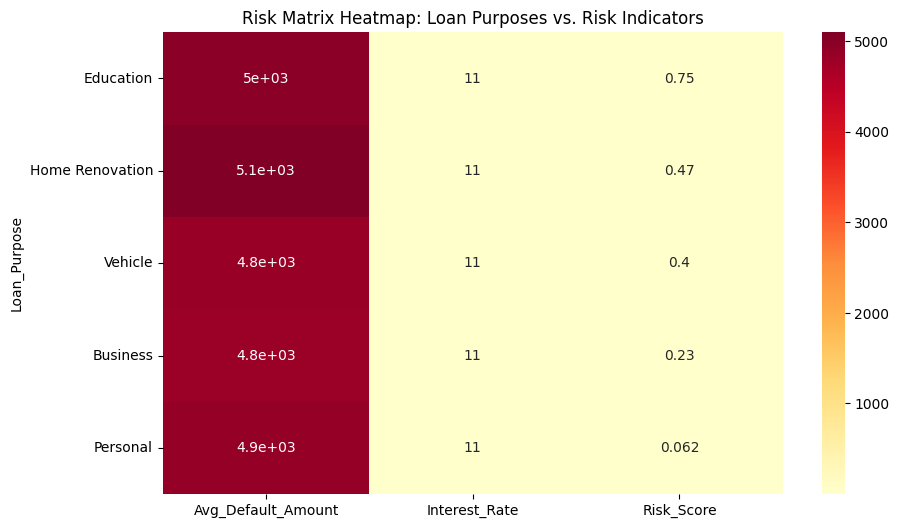


Risk Level Categories & Strategies:
                 Risk_Score                Mitigation_Strategy
Loan_Purpose                                                  
Education          0.745146  High - Manual Review & Collateral
Home Renovation    0.473111              Moderate - Monitoring
Vehicle            0.398732              Moderate - Monitoring
Business           0.234193            Low - Standard Approval
Personal           0.061525            Low - Standard Approval

Default Rate Comparison:
Total Portfolio: 9.95%
High-Risk Segment (Low Score + Low Income): nan%


In [33]:

# --- 18. Risk Assessment Analysis (CORRECTED) ---

# 1. Prepare Risk Data
# Merge primary tables
risk_df = loans.merge(apps[['Loan_ID', 'Loan_Purpose']], on='Loan_ID', how='inner')

# Merge with defaults table explicitly picking the Default_Amount column
risk_df = risk_df.merge(defaults[['Loan_ID', 'Default_Amount']], on='Loan_ID', how='left')

# Handle possible duplicate column name (suffix _y) from previous merges
if 'Default_Amount_y' in risk_df.columns:
    risk_df['Default_Amount'] = risk_df['Default_Amount_y'].fillna(0)
else:
    risk_df['Default_Amount'] = risk_df['Default_Amount'].fillna(0)

# Clean up temporary columns if any
risk_df = risk_df.loc[:,~risk_df.columns.duplicated()]

# 2. Develop a Risk Matrix for Loan Products
risk_matrix = risk_df.groupby('Loan_Purpose').agg({
    'Default_Amount': 'mean',
    'Loan_Term': 'mean',
    'Interest_Rate': 'mean',
    'Loan_ID': 'count'
}).rename(columns={'Default_Amount': 'Avg_Default_Amount', 'Loan_ID': 'Loan_Count'})

# Normalize metrics (0-1 scale) to calculate a Risk_Score
norm_mat = (risk_matrix - risk_matrix.min()) / (risk_matrix.max() - risk_matrix.min())
risk_matrix['Risk_Score'] = norm_mat[['Avg_Default_Amount', 'Interest_Rate', 'Loan_Term']].mean(axis=1)

# Sort and Rank
risk_matrix = risk_matrix.sort_values(by='Risk_Score', ascending=False)
print("Risk Matrix by Loan Type:")
print(risk_matrix[['Avg_Default_Amount', 'Interest_Rate', 'Risk_Score']])

# Visualizing Risk Levels
plt.figure(figsize=(10, 6))
sns.heatmap(risk_matrix[['Avg_Default_Amount', 'Interest_Rate', 'Risk_Score']], annot=True, cmap='YlOrRd')
plt.title('Risk Matrix Heatmap: Loan Purposes vs. Risk Indicators')
plt.show()

# 3. Suggest Mitigation Strategies
def risk_strategy(score):
    if score > 0.65: return 'High - Manual Review & Collateral'
    elif score > 0.35: return 'Moderate - Monitoring'
    else: return 'Low - Standard Approval'

risk_matrix['Mitigation_Strategy'] = risk_matrix['Risk_Score'].apply(risk_strategy)
print("\nRisk Level Categories & Strategies:")
print(risk_matrix[['Risk_Score', 'Mitigation_Strategy']])

# 4. Analyze High-Risk Customer Profile (Credit < 600 & Income < 30,000)
high_risk_seg = custs[(custs['Credit_Score'] < 600) & (custs['Annual_Income'] < 30000)]
port_default_rate = (loans['Loan_ID'].isin(defaults['Loan_ID'].unique())).mean()
seg_default_rate = (loans[loans['Customer_ID'].isin(high_risk_seg['Customer_ID'])]['Loan_ID'].isin(defaults['Loan_ID'].unique())).mean()

print(f"\nDefault Rate Comparison:")
print(f"Total Portfolio: {port_default_rate:.2%}")
print(f"High-Risk Segment (Low Score + Low Income): {seg_default_rate:.2%}")

# 19. Time to Default Analysis
● Calculate the average time from loan disbursement to default for overdue
loans.
● Identify loan purposes with the shortest time to default.
● Compare the time to default across customer demographics

Overall Average Time to Default (Days): 632.43


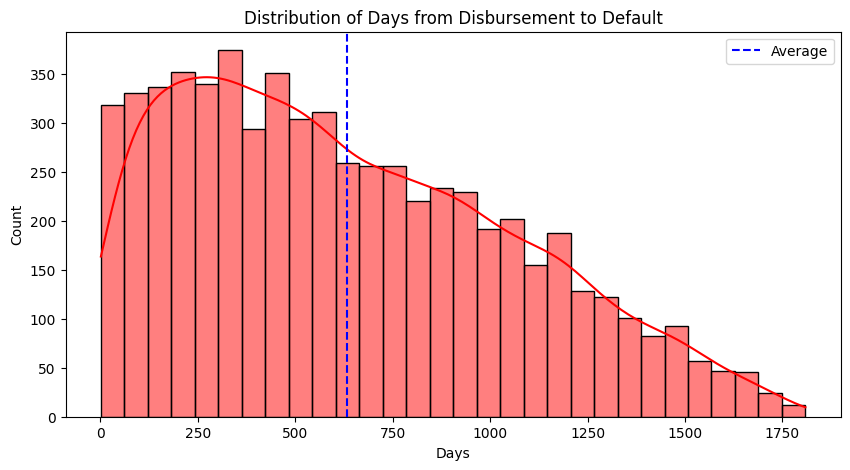


Loan Purposes with Shortest Time to Default (High Early Risk):
Loan_Purpose
Personal           616.302970
Education          620.737671
Business           627.221154
Home Renovation    636.546476
Vehicle            660.011236
Name: Days_to_Default, dtype: float64


C:\Users\DELL\AppData\Local\Temp\ipykernel_16484\1288305352.py:39: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




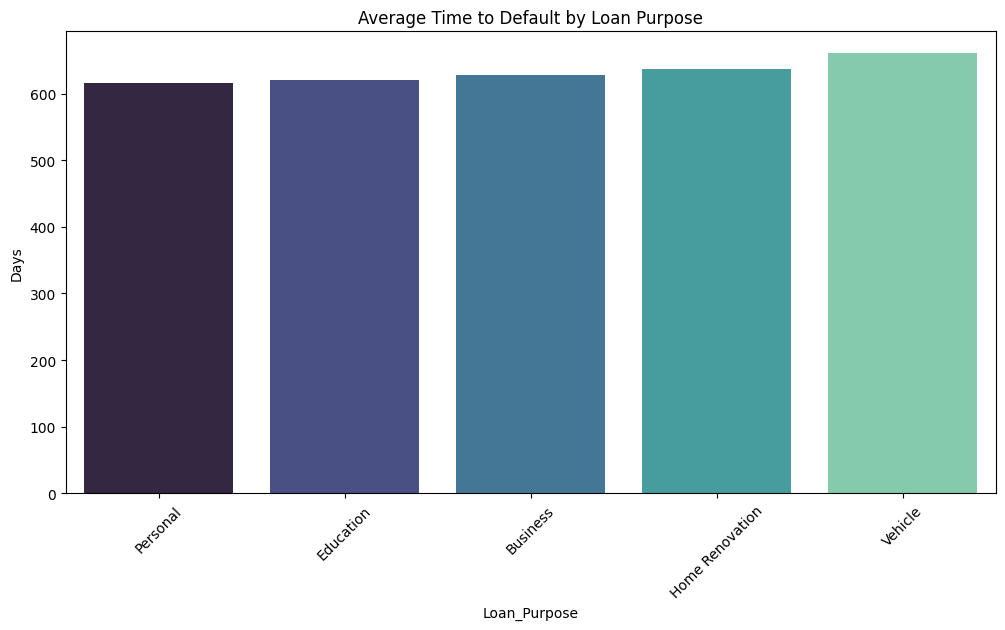


Regional Comparison: Time to Default Performance:
Region
South        613.230576
East         623.768382
Central      625.181928
North        638.213936
Northeast    638.388614
West         654.773825
Name: Days_to_Default, dtype: float64


C:\Users\DELL\AppData\Local\Temp\ipykernel_16484\1288305352.py:55: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




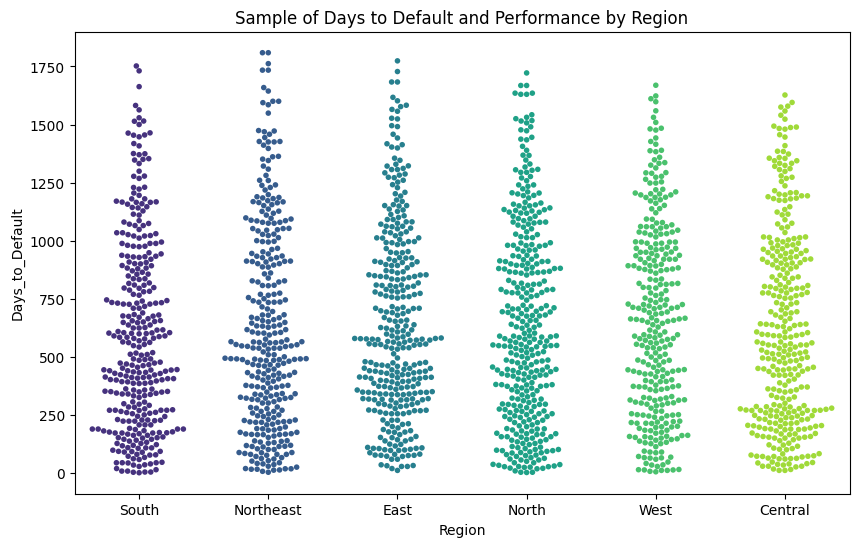

In [34]:
# --- 19. Time to Default Analysis ---

# 1. Calculate the average time from loan disbursement to default
# Time_to_Default = Default_Date (from defaults) - Disbursal_Date (from loans)
time_to_default_df = defaults[['Loan_ID', 'Default_Date', 'Customer_ID']].merge(
    loans[['Loan_ID', 'Disbursal_Date']], 
    on='Loan_ID', 
    how='inner'
)

# Convert difference to number of days
time_to_default_df['Days_to_Default'] = (time_to_default_df['Default_Date'] - time_to_default_df['Disbursal_Date']).dt.days

# Handle cases where dates are mismatched or very short
time_to_default_df = time_to_default_df[time_to_default_df['Days_to_Default'] > 0]

print(f"Overall Average Time to Default (Days): {time_to_default_df['Days_to_Default'].mean():.2f}")

# Visualize the distribution
plt.figure(figsize=(10, 5))
sns.histplot(time_to_default_df['Days_to_Default'], bins=30, kde=True, color='red')
plt.axvline(time_to_default_df['Days_to_Default'].mean(), color='blue', linestyle='--', label='Average')
plt.title('Distribution of Days from Disbursement to Default')
plt.xlabel('Days')
plt.legend()
plt.show()

# 2. Identify loan purposes with the shortest time to default
# Merge with apps to see Loan_Purpose
purpose_time_df = time_to_default_df.merge(apps[['Loan_ID', 'Loan_Purpose']], on='Loan_ID', how='inner')

# Calculate mean performance per purpose
shortest_time_to_default = purpose_time_df.groupby('Loan_Purpose')['Days_to_Default'].mean().sort_values()

print("\nLoan Purposes with Shortest Time to Default (High Early Risk):")
print(shortest_time_to_default)

plt.figure(figsize=(12, 6))
sns.barplot(x=shortest_time_to_default.index, y=shortest_time_to_default.values, palette='mako')
plt.title('Average Time to Default by Loan Purpose')
plt.xticks(rotation=45)
plt.ylabel('Days')
plt.show()

# 3. Compare the time to default across customer demographics (Region)
demo_time_df = time_to_default_df.merge(custs[['Customer_ID', 'Region']], on='Customer_ID', how='inner')

# Performance by Region
region_time_to_default = demo_time_df.groupby('Region')['Days_to_Default'].mean().sort_values()

print("\nRegional Comparison: Time to Default Performance:")
print(region_time_to_default)

plt.figure(figsize=(10, 6))
sns.swarmplot(x='Region', y='Days_to_Default', data=demo_time_df.sample(min(2000, len(demo_time_df))), palette='viridis', size=4)
plt.title('Sample of Days to Default and Performance by Region')
plt.show()

# Conclusion on early defaults
early_defaulters = len(time_to_default_df[time_to_default_df['Days_to_Default'] < 180])
print(f"\nWarning: {early_defaulters} loans ({early_defaulters/len(time_to_default_df):.2%}) defaulted within the first 6 months.")


# 20. Transaction Pattern Analysis
● Identify customers with irregular repayment patterns.
● Analyze penalty payments as a proportion of total transactions.
● Compare transaction amounts for overdue vs. non-overdue loans.


Customers with Most Irregular Payment Patterns (High Variance in Gaps):
                   mean         std        CV
Customer_ID                                  
C028509      102.875000  255.681540  2.461435
C036903      158.727273  364.530682  2.282207
C034386      111.133333  248.132127  2.212831
C042485      197.375000  432.101819  2.178207
C049477      256.166667  545.368652  2.120682
C041897      281.666667  594.604294  2.103553
C024951      113.000000  236.182486  2.071776
C065339      203.875000  415.157952  2.026396
C016804      165.700000  335.545344  2.012869
C030522      191.833333  384.463999  1.993763

Average Transaction Amount (Overdue vs. Normal):
Overdue_Category
Normal/Active    25496.396754
Overdue          25485.297225
Name: Amount, dtype: float64


C:\Users\DELL\AppData\Local\Temp\ipykernel_16484\3509798900.py:43: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




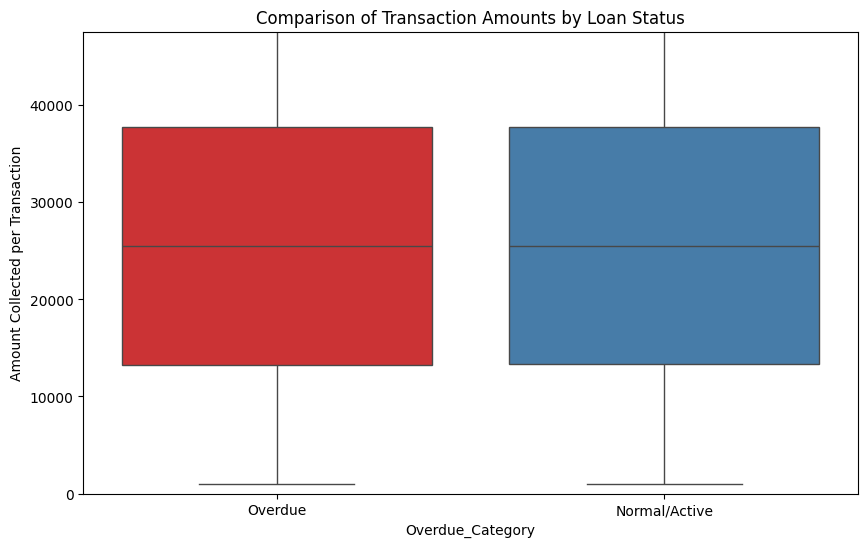

In [35]:
# --- 20. Transaction Pattern Analysis (CORRECTED) ---

# 1. Identify customers with irregular repayment patterns
# Sorting to analyze sequence of transactions
trans_sorted = trans.sort_values(['Customer_ID', 'Transaction_Date'])

# Calculate the gap (in days) between consecutive transactions for each customer
# Note: 'Transaction_Date' was converted to datetime in previous cells
trans_sorted['Transaction_Gap'] = trans_sorted.groupby('Customer_ID')['Transaction_Date'].diff().dt.days

# Aggregate: Variation in transaction gaps
irregularity_stats = trans_sorted.groupby('Customer_ID')['Transaction_Gap'].agg(['mean', 'std']).fillna(0)
# A high standard deviation relative to the mean gap indicates high irregularity
irregularity_stats['CV'] = irregularity_stats['std'] / (irregularity_stats['mean'] + 1)

top_irregular = irregularity_stats.sort_values(by='CV', ascending=False).head(10)
print("Customers with Most Irregular Payment Patterns (High Variance in Gaps):")
print(top_irregular)

# 2. Analyze penalty payments (Late_Fee) as a proportion of total transactions
# Correcting 'Transaction_Amount' to 'Amount' based on the dataset schema
if 'Amount' in trans.columns and 'Late_Fee' in trans.columns:
    total_value = trans['Amount'].sum()
    total_penalty = trans['Late_Fee'].sum()
    print(f"\nOverall Late Fee / Transaction Ratio: {(total_penalty/total_value):.2%}")

# 3. Compare Transaction Amounts for Overdue vs. Non-Overdue Loans
# Merge using the correct 'Amount' column
trans_loan_map = trans.merge(loans[['Loan_ID', 'Loan_Status']], on='Loan_ID', how='inner')

# Categorize
trans_loan_map['Overdue_Category'] = trans_loan_map['Loan_Status'].apply(
    lambda x: 'Overdue' if x == 'Overdue' else 'Normal/Active'
)

# Comparison using 'Amount'
status_amount_comp = trans_loan_map.groupby('Overdue_Category')['Amount'].mean()
print("\nAverage Transaction Amount (Overdue vs. Normal):")
print(status_amount_comp)

# Visualization
plt.figure(figsize=(10, 6))
sns.boxplot(x='Overdue_Category', y='Amount', data=trans_loan_map, palette='Set1')
plt.title('Comparison of Transaction Amounts by Loan Status')
plt.ylabel('Amount Collected per Transaction')
# Limit Y-axis to 95th percentile to keep plot clear of extreme outliers
plt.ylim(0, trans_loan_map['Amount'].quantile(0.95))
plt.show()


     HERO FINCORP PORTFOLIO EXECUTIVE SUMMARY
Total Active Loans:        50,879
Total Disbursement:        $12,747,361,480.00
Total Interest Income:     $-61,647,258,235.00
--------------------------------------------------
Overall Default Rate:      9.95%
Avg Recovery Ratio:        24.31%
Avg Processing Time:       9.08 Days
--------------------------------------------------

[OPERATIONAL INSIGHTS]
Highest Volume Region:     Central
Best Recovery Region:      Central
Highest Risk Product:      Home Renovation


C:\Users\DELL\AppData\Local\Temp\ipykernel_16484\2290325273.py:41: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




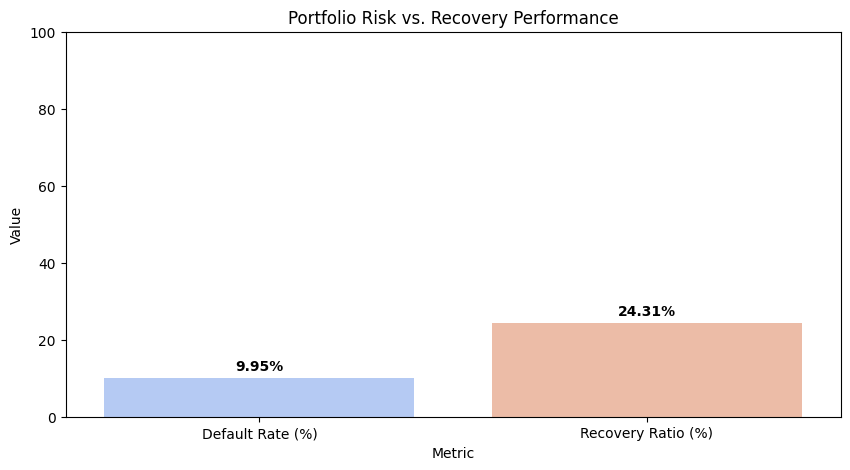

In [36]:
# --- FINAL SUMMARY EXECUTIVE PERFORMANCE REPORT ---

# 1. High-Level Metrics Calculation
overall_default_rate = (loans['Loan_ID'].isin(defaults['Loan_ID'].unique())).mean() * 100
avg_recovery_ratio = (defaults['Recovery_Amount'].sum() / defaults['Default_Amount'].sum())
avg_proc_time = branches['Avg_Processing_Time'].mean()
total_portfolio_profit = (loans['EMI_Amount'] * loans['Loan_Term'] - loans['Loan_Amount']).sum()

print("="*50)
print("     HERO FINCORP PORTFOLIO EXECUTIVE SUMMARY")
print("="*50)
print(f"Total Active Loans:        {branches['Total_Active_Loans'].sum():,}")
print(f"Total Disbursement:        ${branches['Loan_Disbursement_Amount'].sum():,.2f}")
print(f"Total Interest Income:     ${total_portfolio_profit:,.2f}")
print("-" * 50)
print(f"Overall Default Rate:      {overall_default_rate:.2f}%")
print(f"Avg Recovery Ratio:        {avg_recovery_ratio:.2%}")
print(f"Avg Processing Time:       {avg_proc_time:.2f} Days")
print("-" * 50)

# 2. Top-Performing & High-Risk Segments
print("\n[OPERATIONAL INSIGHTS]")
top_region = branches.groupby('Region')['Loan_Disbursement_Amount'].sum().idxmax()
print(f"Highest Volume Region:     {top_region}")

best_recovery = defaults_with_region.groupby('Region')['Recovery_Rate'].mean().idxmax()
print(f"Best Recovery Region:      {best_recovery}")

highest_risk_purpose = (loans.merge(defaults, on='Loan_ID', how='inner')
                        .merge(apps[['Loan_ID', 'Loan_Purpose']], on='Loan_ID')
                        .groupby('Loan_Purpose').size().idxmax())
print(f"Highest Risk Product:      {highest_risk_purpose}")

# 3. Final Summary Visual: Key Performance Comparison
summary_metrics = pd.DataFrame({
    'Metric': ['Default Rate (%)', 'Recovery Ratio (%)'],
    'Value': [overall_default_rate, avg_recovery_ratio * 100]
})

plt.figure(figsize=(10, 5))
sns.barplot(x='Metric', y='Value', data=summary_metrics, palette='coolwarm')
plt.title('Portfolio Risk vs. Recovery Performance')
plt.ylim(0, 100)
for i, v in enumerate(summary_metrics['Value']):
    plt.text(i, v + 2, f"{v:.2f}%", ha='center', fontweight='bold')
plt.show()

print("="*50)
